# Notebook 20 — Manuscript comparison and online runtime validation

## Aim

This notebook compares the dissertation’s independently generated results with the principal numerical claims in the supplied working manuscript by Plath, Rave, Weinhart and Thornton.

It also measures the online evaluation time of the available continuum reduced-order surrogate and its interpolation baselines.

## Questions

1. Does the homogenised small-species volume-fraction field exhibit the low-rank structure reported in the manuscript?
2. Does the independently reconstructed neural-network surrogate reproduce the reported error plateau of approximately 1%?
3. Is the observed neural-network error comparable with the measured finite-duration temporal variability?
4. Does a complete single-parameter continuum-field prediction evaluate in less than one second?
5. How does the tested continuum-first representation compare with the labelled particle-coordinate representations?

## Evidential limits

The manuscript authors’ original implementation is not available in this repository. The neural network used here is an architecture-faithful independent reconstruction using the supplied methodological description and frozen Notebook 14 model packages.

The timing study separates offline construction from online evaluation. It does not execute a new DEM simulation and therefore cannot independently verify the manuscript’s estimate of approximately three days of DEM wall-clock time.

The direct particle comparison concerns only the tested labelled-coordinate POD representations. It is not a universal comparison against every particle-level reduced-order modelling method.

No manuscript figure values will be treated as independently measured data. Claims that cannot be tested from the available artifacts will be marked explicitly as unverified.

In [1]:
import hashlib
import json
import platform
import sys

from datetime import datetime, timezone
from importlib.metadata import version
from pathlib import Path

import pandas as pd

from IPython.display import display


N20_PROTOCOL_FROZEN_AT_UTC = (
    datetime.now(timezone.utc).isoformat()
)


def n20_sha256(path):
    digest = hashlib.sha256()

    with Path(path).open("rb") as handle:
        for chunk in iter(
            lambda: handle.read(1024 * 1024),
            b"",
        ):
            digest.update(chunk)

    return digest.hexdigest()


n20_current_directory = Path.cwd().resolve()

n20_repository_candidates = [
    n20_current_directory,
    *n20_current_directory.parents,
    Path.home()
    / "Documents"
    / "msc-rom-particle-systems",
]

N20_REPO_ROOT = next(
    (
        candidate
        for candidate in n20_repository_candidates
        if (
            (candidate / "notebooks").is_dir()
            and (candidate / "results").is_dir()
            and (candidate / ".venv").is_dir()
        )
    ),
    None,
)

assert N20_REPO_ROOT is not None, (
    "Could not locate the repository root."
)

assert Path(sys.prefix).resolve() == (
    N20_REPO_ROOT / ".venv"
).resolve(), (
    "The notebook is not using the repository .venv kernel."
)


N20_MANIFEST_RELATIVE_PATHS = {
    "notebook_12": (
        "results/tables/multi_parameter_route_order/"
        "multi_parameter_route_order_manifest.json"
    ),
    "notebook_13": (
        "results/tables/"
        "xz_particle_representation_sensitivity/"
        "xz_particle_representation_sensitivity_manifest.json"
    ),
    "notebook_14": (
        "results/tables/exact_paper_method_reproduction/"
        "exact_paper_method_reproduction_manifest.json"
    ),
    "notebook_18": (
        "results/tables/coefficient_baselines/"
        "notebook18_final_integrity_manifest.json"
    ),
    "notebook_19": (
        "results/tables/observable_matched_particle_pod/"
        "notebook19_observable_matched_manifest.json"
    ),
}


N20_EXPECTED_MANIFEST_HASHES = {
    "notebook_12": (
        "f093f7de958f5fcd6860ebcfee8416af27aa01d4b1c8ed1488e05d7fb8e9e844"
    ),
    "notebook_13": (
        "389bb1a53975fe098c7da908b5886adfb42f13237f6c6464b3c170f7b6d0cfce"
    ),
    "notebook_14": (
        "f15744e23b1bfc3898750a1e2fb2504a2d3ca9c6c96c714188a4094d0357604f"
    ),
    "notebook_18": (
        "6aba1fbde7b179f9cbc242e8490034e9271b770745c3361c98cb209599868556"
    ),
    "notebook_19": (
        "34516a68749b805a1152d7e5fd1920f59f84ed7a2d68ce1fe09e72dbed927403"
    ),
}


N20_MANIFESTS = {}
N20_MANIFEST_PATHS = {}
n20_manifest_rows = []


for role, relative_path in (
    N20_MANIFEST_RELATIVE_PATHS.items()
):
    path = N20_REPO_ROOT / relative_path

    assert path.is_file(), f"Missing manifest: {path}"

    observed_hash = n20_sha256(path)
    expected_hash = (
        N20_EXPECTED_MANIFEST_HASHES[role]
    )
    hash_match = observed_hash == expected_hash

    assert hash_match, (
        f"{role} manifest hash mismatch.\n"
        f"Expected: {expected_hash}\n"
        f"Observed: {observed_hash}"
    )

    manifest = json.loads(
        path.read_text(encoding="utf-8")
    )

    N20_MANIFESTS[role] = manifest
    N20_MANIFEST_PATHS[role] = path

    n20_manifest_rows.append(
        {
            "manifest": role,
            "relative_path": relative_path,
            "sha256": observed_hash,
            "hash_match": hash_match,
        }
    )


N20_MANIFEST_AUDIT = pd.DataFrame(
    n20_manifest_rows
)

display(N20_MANIFEST_AUDIT)


N20_HASH_RECORDS = {}
N20_HASH_CONFLICTS = []


def n20_collect_hash_records(value):
    if isinstance(value, dict):
        if {
            "relative_path",
            "sha256",
        }.issubset(value):
            relative_path = str(
                value["relative_path"]
            )
            recorded_hash = str(
                value["sha256"]
            )

            previous_hash = N20_HASH_RECORDS.get(
                relative_path
            )

            if (
                previous_hash is not None
                and previous_hash != recorded_hash
            ):
                N20_HASH_CONFLICTS.append(
                    {
                        "relative_path": relative_path,
                        "first_hash": previous_hash,
                        "second_hash": recorded_hash,
                    }
                )
            else:
                N20_HASH_RECORDS[
                    relative_path
                ] = recorded_hash

        for nested_value in value.values():
            n20_collect_hash_records(
                nested_value
            )

    elif isinstance(value, list):
        for nested_value in value:
            n20_collect_hash_records(
                nested_value
            )


for manifest in N20_MANIFESTS.values():
    n20_collect_hash_records(manifest)


assert not N20_HASH_CONFLICTS, (
    f"Conflicting upstream hashes: "
    f"{N20_HASH_CONFLICTS}"
)


N20_PACKAGE_VERSIONS = {
    package: version(package)
    for package in (
        "numpy",
        "pandas",
        "scipy",
        "torch",
        "matplotlib",
    )
}


print("Python executable:", sys.executable)
print("Python version:", platform.python_version())
print("Repository root:", N20_REPO_ROOT)
print("Package versions:", N20_PACKAGE_VERSIONS)
print(
    "Protocol frozen at UTC:",
    N20_PROTOCOL_FROZEN_AT_UTC,
)
print(
    "Hash-bearing artifact records collected:",
    len(N20_HASH_RECORDS),
)
print("Numerical model arrays loaded:", False)
print("Raw DEM files accessed:", False)
print("Files written by this cell:", False)
print("Notebook 20 manifest preflight passed:", True)

,manifest,relative_path,sha256,hash_match
0,notebook_12,results/tables/multi_parameter_route_order/mul...,f093f7de958f5fcd6860ebcfee8416af27aa01d4b1c8ed...,True
1,notebook_13,results/tables/xz_particle_representation_sens...,389bb1a53975fe098c7da908b5886adfb42f13237f6c64...,True
2,notebook_14,results/tables/exact_paper_method_reproduction...,f15744e23b1bfc3898750a1e2fb2504a2d3ca9c6c96c71...,True
3,notebook_18,results/tables/coefficient_baselines/notebook1...,6aba1fbde7b179f9cbc242e8490034e9271b770745c336...,True
4,notebook_19,results/tables/observable_matched_particle_pod...,34516a68749b805a1152d7e5fd1920f59f84ed7a2d68ce...,True


Python executable: /Users/rallen/Documents/msc-rom-particle-systems/.venv/bin/python
Python version: 3.12.1
Repository root: /Users/rallen/Documents/msc-rom-particle-systems
Package versions: {'numpy': '1.26.4', 'pandas': '3.0.3', 'scipy': '1.17.1', 'torch': '2.2.2', 'matplotlib': '3.11.0'}
Protocol frozen at UTC: 2026-09-09T15:43:38.891238+00:00
Hash-bearing artifact records collected: 91
Numerical model arrays loaded: False
Raw DEM files accessed: False
Files written by this cell: False
Notebook 20 manifest preflight passed: True


In [2]:
N20_INPUT_RELATIVE_PATHS = {
    "n12_rank100_summary": (
        "results/tables/multi_parameter_route_order/"
        "multi_parameter_rank_100_summary.csv"
    ),
    "n13_xz_rank100_summary": (
        "results/tables/"
        "xz_particle_representation_sensitivity/"
        "xz_rank_100_summary.csv"
    ),
    "n14_tail_diagnostics": (
        "results/tables/exact_paper_method_reproduction/"
        "centred_uncentred_tail_diagnostics.csv"
    ),
    "n14_rank_criteria": (
        "results/tables/exact_paper_method_reproduction/"
        "relative_tail_rank_criteria.csv"
    ),
    "n14_training_sweep": (
        "results/tables/exact_paper_method_reproduction/"
        "paper_rank_training_external_errors.csv"
    ),
    "n14_selected_models": (
        "results/tables/exact_paper_method_reproduction/"
        "paper_rank_training_selected_models.csv"
    ),
    "n14_final_summary": (
        "results/tables/exact_paper_method_reproduction/"
        "final_continuum_rom_comparison.csv"
    ),
    "n14_final_cases": (
        "results/tables/exact_paper_method_reproduction/"
        "final_continuum_rom_test_cases.csv"
    ),
    "n14_dataset": (
        "data/processed/cg_phi_small_dataset.npz"
    ),
    "n14_rank6_package": (
        "data/processed/"
        "cg_phi_validation_selected_rank_uncentred_raw.pt"
    ),
    "n14_rank15_package": (
        "data/processed/"
        "cg_phi_paper_rank15_uncentred_raw.pt"
    ),
    "n15_modewise_comparison": (
        "results/tables/"
        "statistical_uncertainty_accuracy_floor/"
        "stage4_modewise_rom_uncertainty_comparison.csv"
    ),
    "n15_rom_decomposition": (
        "results/tables/"
        "statistical_uncertainty_accuracy_floor/"
        "stage4_rom_error_decomposition.csv"
    ),
    "n15_duration_scaling": (
        "results/tables/"
        "statistical_uncertainty_accuracy_floor/"
        "variable_duration_scaling_summary.csv"
    ),
    "n15_validation_checks": (
        "results/tables/"
        "statistical_uncertainty_accuracy_floor/"
        "stage4_validation_checks.csv"
    ),
    "n18_method_summary": (
        "results/tables/coefficient_baselines/"
        "method_summary.csv"
    ),
    "n18_paired_summary": (
        "results/tables/coefficient_baselines/"
        "paired_method_summary.csv"
    ),
    "n18_loo_summary": (
        "results/tables/coefficient_baselines/"
        "loo_interpolation_summary.csv"
    ),
    "n18_validation_audit": (
        "results/tables/coefficient_baselines/"
        "validation_audit.csv"
    ),
    "n19_small_only_sweep": (
        "results/tables/"
        "observable_matched_particle_pod/"
        "small_only_pod_sweep.csv"
    ),
    "n19_rank100_comparison": (
        "results/tables/"
        "observable_matched_particle_pod/"
        "rank100_comparison.csv"
    ),
    "n19_row_continuity": (
        "results/tables/"
        "observable_matched_particle_pod/"
        "row_continuity_summary.csv"
    ),
}


N20_INPUT_PATHS = {}
n20_input_rows = []


for role, relative_path in (
    N20_INPUT_RELATIVE_PATHS.items()
):
    path = N20_REPO_ROOT / relative_path

    assert path.is_file(), (
        f"Missing Notebook 20 input: {path}"
    )

    observed_hash = n20_sha256(path)
    recorded_hash = N20_HASH_RECORDS.get(
        relative_path
    )

    upstream_hash_available = (
        recorded_hash is not None
    )

    upstream_hash_match = (
        observed_hash == recorded_hash
        if upstream_hash_available
        else None
    )

    # Notebook 15 has no final comprehensive manifest.
    # Its hashes are therefore frozen here for the new
    # Notebook 20 manifest.
    if not role.startswith("n15_"):
        assert upstream_hash_available, (
            f"No upstream hash found for {role}: "
            f"{relative_path}"
        )

        assert upstream_hash_match, (
            f"Upstream hash mismatch for {role}: "
            f"{relative_path}"
        )

    N20_INPUT_PATHS[role] = path

    n20_input_rows.append(
        {
            "input_role": role,
            "relative_path": relative_path,
            "size_MiB": (
                path.stat().st_size
                / 1024**2
            ),
            "sha256": observed_hash,
            "upstream_hash_available": (
                upstream_hash_available
            ),
            "upstream_hash_match": (
                upstream_hash_match
            ),
        }
    )


N20_INPUT_AUDIT = pd.DataFrame(
    n20_input_rows
)


display(
    N20_INPUT_AUDIT[
        [
            "input_role",
            "size_MiB",
            "upstream_hash_available",
            "upstream_hash_match",
        ]
    ]
)


assert len(N20_INPUT_AUDIT) == len(
    N20_INPUT_RELATIVE_PATHS
)

assert N20_INPUT_AUDIT[
    "sha256"
].str.fullmatch(
    r"[0-9a-f]{64}"
).all()


print(
    "Targeted inputs checked:",
    len(N20_INPUT_AUDIT),
)
print(
    "Manifest-verified inputs:",
    int(
        N20_INPUT_AUDIT[
            "upstream_hash_available"
        ].sum()
    ),
)
print(
    "Notebook 15 inputs frozen by Notebook 20:",
    int(
        (
            ~N20_INPUT_AUDIT[
                "upstream_hash_available"
            ]
        ).sum()
    ),
)
print("Numerical model arrays loaded:", False)
print("Raw DEM files accessed:", False)
print("Files written by this cell:", False)
print("Notebook 20 targeted-input audit passed:", True)

,input_role,size_MiB,upstream_hash_available,upstream_hash_match
0,n12_rank100_summary,0.002238,True,True
1,n13_xz_rank100_summary,0.001774,True,True
2,n14_tail_diagnostics,0.002052,True,True
3,n14_rank_criteria,0.000270,True,True
4,n14_training_sweep,0.003008,True,True
5,n14_selected_models,0.002498,True,True
6,n14_final_summary,0.000975,True,True
7,n14_final_cases,0.001550,True,True
8,n14_dataset,3.253745,True,True
9,n14_rank6_package,0.594852,True,True


Targeted inputs checked: 22
Manifest-verified inputs: 18
Notebook 15 inputs frozen by Notebook 20: 4
Numerical model arrays loaded: False
Raw DEM files accessed: False
Files written by this cell: False
Notebook 20 targeted-input audit passed: True


In [3]:
N20_TABLES = {}
n20_schema_rows = []


for role, path in N20_INPUT_PATHS.items():
    if path.suffix.lower() != ".csv":
        continue

    table = pd.read_csv(path)

    assert len(table) > 0, (
        f"Empty input table: {role}"
    )

    assert not table.columns.duplicated().any(), (
        f"Duplicate columns in: {role}"
    )

    N20_TABLES[role] = table

    n20_schema_rows.append(
        {
            "input_role": role,
            "row_count": len(table),
            "column_count": len(table.columns),
            "columns": ", ".join(
                map(
                    str,
                    table.columns,
                )
            ),
        }
    )


N20_SCHEMA_AUDIT = pd.DataFrame(
    n20_schema_rows
)


for _, row in N20_SCHEMA_AUDIT.iterrows():
    print()
    print(
        row["input_role"],
        "shape=",
        (
            int(row["row_count"]),
            int(row["column_count"]),
        ),
    )
    print(
        "columns:",
        row["columns"],
    )


N20_MANUSCRIPT_CLAIMS = pd.DataFrame(
    [
        {
            "claim_id": "M1",
            "manuscript_claim": (
                "Homogenised particle snapshots exhibit "
                "rapidly decaying low-rank structure, with "
                "rank 15 selected near the error plateau."
            ),
            "manuscript_location": "Sections 6.1–6.2",
            "status_before_n20": "directly testable",
            "planned_evidence": (
                "Notebook 14 spectrum, rank and "
                "projection diagnostics"
            ),
        },
        {
            "claim_id": "M2",
            "manuscript_claim": (
                "Neural-network prediction error "
                "stabilises at approximately 1 percent "
                "once the principal modes are retained."
            ),
            "manuscript_location": "Section 6.2",
            "status_before_n20": "directly testable",
            "planned_evidence": (
                "Notebook 14 independent external errors"
            ),
        },
        {
            "claim_id": "M3",
            "manuscript_claim": (
                "The prediction plateau is comparable "
                "with finite-duration temporal "
                "variability in the homogenised data."
            ),
            "manuscript_location": "Section 6.3",
            "status_before_n20": "qualified test",
            "planned_evidence": (
                "Notebook 15 duration-matched empirical "
                "variability comparison"
            ),
        },
        {
            "claim_id": "M4",
            "manuscript_claim": (
                "An online surrogate evaluation takes "
                "well below one second."
            ),
            "manuscript_location": "Sections 6.4 and 7",
            "status_before_n20": "requires timing",
            "planned_evidence": (
                "Repeated warm single-query timing of "
                "coefficient prediction and field "
                "reconstruction"
            ),
        },
        {
            "claim_id": "M5",
            "manuscript_claim": (
                "The surrogate reduces a roughly "
                "three-day DEM calculation to seconds."
            ),
            "manuscript_location": "Sections 6.4 and 7",
            "status_before_n20": "partially testable",
            "planned_evidence": (
                "Measure the surrogate side only; retain "
                "the DEM duration as a manuscript-reported "
                "value"
            ),
        },
        {
            "claim_id": "M6",
            "manuscript_claim": (
                "The surrogate captures the variation of "
                "segregation with particle-size ratio."
            ),
            "manuscript_location": "Section 6.4",
            "status_before_n20": (
                "partial observable match"
            ),
            "planned_evidence": (
                "Available small-species volume-fraction "
                "test fields; no independent recreation "
                "of the manuscript mixing index"
            ),
        },
        {
            "claim_id": "M7",
            "manuscript_claim": (
                "Homogenisation enables a more efficient "
                "low-rank representation than direct "
                "particle-coordinate reduction."
            ),
            "manuscript_location": (
                "Introduction and Sections 3–4"
            ),
            "status_before_n20": (
                "tested representation only"
            ),
            "planned_evidence": (
                "Notebooks 12, 13 and 19 continuum-first "
                "versus labelled-coordinate results"
            ),
        },
    ]
)


display(N20_MANUSCRIPT_CLAIMS)


assert len(N20_TABLES) == 19

assert set(
    N20_MANUSCRIPT_CLAIMS[
        "claim_id"
    ]
) == {
    "M1",
    "M2",
    "M3",
    "M4",
    "M5",
    "M6",
    "M7",
}


print(
    "CSV tables loaded:",
    len(N20_TABLES),
)
print(
    "Manuscript claims registered:",
    len(N20_MANUSCRIPT_CLAIMS),
)
print("Model packages deserialised:", False)
print("Raw DEM files accessed:", False)
print(
    "External test cases used for selection:",
    False,
)
print("Files written by this cell:", False)
print(
    "Notebook 20 Stage 1 preflight passed:",
    True,
)


n12_rank100_summary shape= (5, 24)
columns: case_id, size_ratio, simulation_number, particle_count, small_particle_count, training_snapshot_count, validation_snapshot_count, continuum_spacetime_error_percent, particle_spacetime_error_percent, continuum_time_averaged_error_percent, particle_time_averaged_error_percent, continuum_mean_spatial_correlation, particle_mean_spatial_correlation, continuum_maximum_volume_fraction, particle_maximum_volume_fraction, continuum_minimum_volume_fraction, particle_minimum_volume_fraction, continuum_fraction_phi_gt_one_percent, particle_fraction_phi_gt_one_percent, continuum_fraction_phi_lt_tolerance_percent, particle_fraction_phi_lt_tolerance_percent, natural_cycle_error_percent, small_particle_fraction, particle_first_to_continuum_first_ratio

n13_xz_rank100_summary shape= (5, 17)
columns: case_id, size_ratio, continuum_first_error_percent, XYZ_particle_error_percent, XZ_particle_error_percent, XZ_time_averaged_error_percent, XZ_mean_correlation, XZ

,claim_id,manuscript_claim,manuscript_location,status_before_n20,planned_evidence
0,M1,Homogenised particle snapshots exhibit rapidly...,Sections 6.1–6.2,directly testable,"Notebook 14 spectrum, rank and projection diag..."
1,M2,Neural-network prediction error stabilises at ...,Section 6.2,directly testable,Notebook 14 independent external errors
2,M3,The prediction plateau is comparable with fini...,Section 6.3,qualified test,Notebook 15 duration-matched empirical variabi...
3,M4,An online surrogate evaluation takes well belo...,Sections 6.4 and 7,requires timing,Repeated warm single-query timing of coefficie...
4,M5,The surrogate reduces a roughly three-day DEM ...,Sections 6.4 and 7,partially testable,Measure the surrogate side only; retain the DE...
5,M6,The surrogate captures the variation of segreg...,Section 6.4,partial observable match,Available small-species volume-fraction test f...
6,M7,Homogenisation enables a more efficient low-ra...,Introduction and Sections 3–4,tested representation only,"Notebooks 12, 13 and 19 continuum-first versus..."


CSV tables loaded: 19
Manuscript claims registered: 7
Model packages deserialised: False
Raw DEM files accessed: False
External test cases used for selection: False
Files written by this cell: False
Notebook 20 Stage 1 preflight passed: True


## Stage 2 — Quantitative comparison with the supplied manuscript

This stage compares previously validated results with the manuscript claims. No models are retrained and no external test case is used for model selection.

The field error is

$$
E(\widehat{u},u)
=
100\frac{\lVert \widehat{u}-u\rVert_2}
{\lVert u\rVert_2}.
$$

Consequently, an error above 100% is mathematically possible: it means that the error norm exceeds the norm of the reference field. It does not mean that a volume fraction exceeds its physical upper bound.

For the phrase “approximately 1%”, the following deliberately broad descriptive interval is reported:

$$
0.5\% \leq E \leq 1.5\%.
$$

This interval is not used for model selection.

The temporal-variability comparison is treated as an empirical diagnostic rather than formal uncertainty quantification. Similar magnitude does not establish that temporal averaging caused the prediction error.

In [4]:
import numpy as np


n20_tail_diagnostics = N20_TABLES[
    "n14_tail_diagnostics"
].copy()

n20_rank_criteria = N20_TABLES[
    "n14_rank_criteria"
].copy()

n20_training_sweep = N20_TABLES[
    "n14_training_sweep"
].copy()

n20_final_summary = N20_TABLES[
    "n14_final_summary"
].copy()


n20_uncentred_tail = (
    n20_tail_diagnostics.loc[
        n20_tail_diagnostics[
            "formulation"
        ]
        .astype(str)
        .str.contains(
            "uncentred",
            case=False,
            na=False,
        )
    ]
    .sort_values("rank")
    .reset_index(drop=True)
)


n20_rank15_tail = (
    n20_uncentred_tail.loc[
        n20_uncentred_tail["rank"].eq(15)
    ]
)

assert len(n20_rank15_tail) == 1


n20_uncentred_rank_criteria = (
    n20_rank_criteria.loc[
        n20_rank_criteria[
            "formulation"
        ]
        .astype(str)
        .str.contains(
            "uncentred",
            case=False,
            na=False,
        )
    ]
    .sort_values(
        "relative_tail_target_percent"
    )
    .reset_index(drop=True)
)


n20_one_percent_rank = (
    n20_uncentred_rank_criteria.loc[
        np.isclose(
            n20_uncentred_rank_criteria[
                "relative_tail_target_percent"
            ],
            1.0,
            rtol=0.0,
            atol=1.0e-12,
        ),
        "smallest_rank",
    ]
)

assert len(n20_one_percent_rank) == 1


n20_training90 = (
    n20_training_sweep.loc[
        n20_training_sweep[
            "training_count"
        ].eq(90)
    ]
    .sort_values("rank")
    .reset_index(drop=True)
)


N20_EXPECTED_SWEEP_RANKS = {
    1,
    2,
    3,
    4,
    6,
    10,
    15,
    20,
}

assert set(
    n20_training90["rank"].astype(int)
) == N20_EXPECTED_SWEEP_RANKS


N20_PLATEAU_RANKS = {
    4,
    6,
    10,
    15,
    20,
}

n20_plateau_rows = (
    n20_training90.loc[
        n20_training90[
            "rank"
        ].isin(N20_PLATEAU_RANKS)
    ]
)

assert len(n20_plateau_rows) == 5


n20_paper_rank15_final = (
    n20_final_summary.loc[
        n20_final_summary[
            "model"
        ].eq("paper_rank15")
    ]
)

assert len(n20_paper_rank15_final) == 1

n20_paper_rank15_final = (
    n20_paper_rank15_final.iloc[0]
)


n20_plateau_minimum = float(
    n20_plateau_rows[
        "mean_external_error_percent"
    ].min()
)

n20_plateau_maximum = float(
    n20_plateau_rows[
        "mean_external_error_percent"
    ].max()
)

n20_plateau_spread = (
    n20_plateau_maximum
    - n20_plateau_minimum
)


N20_CONTINUUM_MANUSCRIPT_COMPARISON = (
    pd.DataFrame(
        [
            {
                "paper_prescribed_rank": 15,
                "smallest_rank_below_one_percent_tail": int(
                    n20_one_percent_rank.iloc[0]
                ),
                "rank15_relative_tail_percent": float(
                    n20_rank15_tail[
                        "relative_tail_percent"
                    ].iloc[0]
                ),
                "rank15_captured_energy_percent": float(
                    n20_rank15_tail[
                        "captured_energy_percent"
                    ].iloc[0]
                ),
                "rank15_mean_external_error_percent": float(
                    n20_paper_rank15_final[
                        "mean_test_error_percent"
                    ]
                ),
                "rank15_median_external_error_percent": float(
                    n20_paper_rank15_final[
                        "median_test_error_percent"
                    ]
                ),
                "rank15_maximum_external_error_percent": float(
                    n20_paper_rank15_final[
                        "maximum_test_error_percent"
                    ]
                ),
                "rank15_mean_projection_error_percent": float(
                    n20_paper_rank15_final[
                        "mean_projection_error_percent"
                    ]
                ),
                "rank15_mean_spatial_correlation": float(
                    n20_paper_rank15_final[
                        "mean_spatial_correlation"
                    ]
                ),
                "rank4_to_rank20_external_error_minimum_percent": (
                    n20_plateau_minimum
                ),
                "rank4_to_rank20_external_error_maximum_percent": (
                    n20_plateau_maximum
                ),
                "rank4_to_rank20_external_error_spread_points": (
                    n20_plateau_spread
                ),
            }
        ]
    )
)


N20_RANK_TRAINING_VIEW = (
    n20_training90[
        [
            "training_count",
            "rank",
            "selected_seed",
            "validation_mean_field_error_percent",
            "mean_external_error_percent",
            "maximum_external_error_percent",
            "mean_projection_error_percent",
            "mean_excess_above_projection_percent",
        ]
    ]
    .copy()
)


display(N20_RANK_TRAINING_VIEW)

print(
    "Manuscript-aligned continuum comparison:"
)

display(
    N20_CONTINUUM_MANUSCRIPT_COMPARISON.T
)


n20_rank15_mean_error = float(
    n20_paper_rank15_final[
        "mean_test_error_percent"
    ]
)

N20_ORDER_ONE_PERCENT_CRITERION = (
    0.5
    <= n20_rank15_mean_error
    <= 1.5
)


assert np.isfinite(
    N20_CONTINUUM_MANUSCRIPT_COMPARISON
    .select_dtypes(
        include=[np.number]
    )
    .to_numpy()
).all()


print(
    "Rank-15 mean error lies between 0.5% and 1.5%:",
    N20_ORDER_ONE_PERCENT_CRITERION,
)
print(
    "Rank 4–20 external-error spread "
    "(percentage points):",
    n20_plateau_spread,
)
print(
    "External test cases used for selection:",
    False,
)
print("Files written by this cell:", False)
print(
    "Notebook 20 low-rank and error-plateau "
    "comparison passed:",
    True,
)

,training_count,rank,selected_seed,validation_mean_field_error_percent,mean_external_error_percent,maximum_external_error_percent,mean_projection_error_percent,mean_excess_above_projection_percent
0,90,1,11,10.335896,11.242849,29.873397,11.239079,0.003770
1,90,2,47,3.122450,2.499039,3.848935,2.459688,0.039351
2,90,3,11,1.097335,0.978811,1.504201,0.792195,0.186616
3,90,4,11,1.034868,0.876312,1.404584,0.629562,0.246750
4,90,6,131,1.018710,0.857850,1.328504,0.533321,0.324529
5,90,10,47,1.023677,0.860217,1.398838,0.411668,0.448550
6,90,15,11,1.032629,0.859868,1.449864,0.361168,0.498699
7,90,20,47,1.036093,0.870857,1.379918,0.329675,0.541182


Manuscript-aligned continuum comparison:


,0
paper_prescribed_rank,15.000000
smallest_rank_below_one_percent_tail,3.000000
rank15_relative_tail_percent,0.298125
rank15_captured_energy_percent,99.999111
rank15_mean_external_error_percent,0.859868
rank15_median_external_error_percent,0.825467
rank15_maximum_external_error_percent,1.449864
rank15_mean_projection_error_percent,0.361168
rank15_mean_spatial_correlation,0.999949
rank4_to_rank20_external_error_minimum_percent,0.857850


Rank-15 mean error lies between 0.5% and 1.5%: True
Rank 4–20 external-error spread (percentage points): 0.018461596710301453
External test cases used for selection: False
Files written by this cell: False
Notebook 20 low-rank and error-plateau comparison passed: True


In [5]:
n20_rom_decomposition = N20_TABLES[
    "n15_rom_decomposition"
].copy()

n20_external_primary = (
    n20_rom_decomposition.loc[
        n20_rom_decomposition[
            "evaluation_role"
        ].eq("external")
        & n20_rom_decomposition[
            "duration_scaling"
        ].eq("empirical_primary")
    ]
    .copy()
)


assert len(n20_external_primary) == 20

assert not n20_external_primary[
    "external_test_used_for_selection"
].astype(bool).any()


n20_variability_rows = []


for (
    n20_model,
    n20_rank,
), n20_group in (
    n20_external_primary.groupby(
        [
            "model",
            "rank",
        ],
        sort=True,
    )
):
    assert len(n20_group) == 10

    n20_field_ratio_values = (
        n20_group.loc[
            n20_group[
                "field_ratio_stable"
            ].astype(bool),
            "rom_to_field_uncertainty_ratio",
        ]
        .to_numpy(dtype=float)
    )

    n20_modal_ratio_values = (
        n20_group.loc[
            n20_group[
                "modal_vector_ratio_stable"
            ].astype(bool),
            "coefficient_to_modal_uncertainty_ratio",
        ]
        .to_numpy(dtype=float)
    )

    assert len(n20_field_ratio_values) > 0
    assert len(n20_modal_ratio_values) > 0

    n20_variability_rows.append(
        {
            "model": n20_model,
            "rank": int(n20_rank),
            "external_case_count": len(
                n20_group
            ),
            "mean_rom_error_percent": float(
                n20_group[
                    "rom_error_percent"
                ].mean()
            ),
            "mean_field_variability_percent": float(
                n20_group[
                    "field_uncertainty_percent"
                ].mean()
            ),
            "ratio_of_mean_rom_to_field_variability": float(
                n20_group[
                    "rom_error_percent"
                ].mean()
                / n20_group[
                    "field_uncertainty_percent"
                ].mean()
            ),
            "median_casewise_rom_to_field_variability_ratio": float(
                np.median(
                    n20_field_ratio_values
                )
            ),
            "fraction_rom_not_above_field_variability": float(
                (
                    n20_field_ratio_values
                    <= 1.0
                ).mean()
            ),
            "mean_coefficient_error_percent": float(
                n20_group[
                    "coefficient_error_percent"
                ].mean()
            ),
            "mean_modal_variability_norm_percent": float(
                n20_group[
                    "modal_uncertainty_norm_percent"
                ].mean()
            ),
            "ratio_of_mean_coefficient_to_modal_variability": float(
                n20_group[
                    "coefficient_error_percent"
                ].mean()
                / n20_group[
                    "modal_uncertainty_norm_percent"
                ].mean()
            ),
            "median_casewise_coefficient_to_modal_variability_ratio": float(
                np.median(
                    n20_modal_ratio_values
                )
            ),
            "fraction_coefficient_error_not_above_modal_variability": float(
                (
                    n20_modal_ratio_values
                    <= 1.0
                ).mean()
            ),
        }
    )


N20_VARIABILITY_COMPARISON = pd.DataFrame(
    n20_variability_rows
)


display(
    N20_VARIABILITY_COMPARISON.T
)


n20_method_summary = N20_TABLES[
    "n18_method_summary"
].copy()


N20_EXTERNAL_BASELINE_COMPARISON = (
    n20_method_summary.loc[
        n20_method_summary[
            "evaluation_role"
        ].eq("external"),
        [
            "model",
            "rank",
            "method",
            "case_count",
            "mean_projection_error_percent",
            "mean_coefficient_error_percent",
            "mean_rom_error_percent",
            "median_rom_error_percent",
            "maximum_rom_error_percent",
            "minimum_prediction",
            "maximum_prediction",
        ],
    ]
    .sort_values(
        [
            "rank",
            "method",
        ]
    )
    .reset_index(drop=True)
)


assert len(
    N20_EXTERNAL_BASELINE_COMPARISON
) == 6

assert (
    N20_EXTERNAL_BASELINE_COMPARISON[
        "case_count"
    ] == 10
).all()


print(
    "External neural-network and "
    "interpolation comparison:"
)

display(N20_EXTERNAL_BASELINE_COMPARISON)


print(
    "Temporal variability interpretation:",
    (
        "The ratios are empirical scale comparisons; "
        "they do not establish a formal uncertainty "
        "bound or a causal accuracy floor."
    ),
)
print(
    "External cases used to construct interpolation:",
    False,
)
print(
    "External cases used for model selection:",
    False,
)
print("Files written by this cell:", False)
print(
    "Notebook 20 variability and baseline "
    "comparison passed:",
    True,
)

,0,1
model,paper_rank15,validation_selected_rank
rank,15,6
external_case_count,10,10
mean_rom_error_percent,0.859868,0.85785
mean_field_variability_percent,0.930909,0.930909
ratio_of_mean_rom_to_field_variability,0.923686,0.921518
median_casewise_rom_to_field_variability_ratio,0.887348,0.860363
fraction_rom_not_above_field_variability,0.6,0.7
mean_coefficient_error_percent,0.773691,0.651069
mean_modal_variability_norm_percent,0.56699,0.366296


External neural-network and interpolation comparison:


,model,rank,method,case_count,mean_projection_error_percent,mean_coefficient_error_percent,mean_rom_error_percent,median_rom_error_percent,maximum_rom_error_percent,minimum_prediction,maximum_prediction
0,validation_selected_rank,6,frozen_nn,10,0.533321,0.651069,0.857850,0.814311,1.328504,-0.000001,0.537657
1,validation_selected_rank,6,pchip,10,0.533321,0.744099,0.930826,0.820105,1.840082,-0.000002,0.537487
2,validation_selected_rank,6,piecewise_linear,10,0.533321,0.705942,0.903362,0.802256,1.804175,-0.000002,0.537410
3,paper_rank15,15,frozen_nn,10,0.361168,0.773691,0.859868,0.825467,1.449864,-0.000003,0.538027
4,paper_rank15,15,pchip,10,0.361168,0.939027,1.011759,0.874773,2.063534,-0.000011,0.538061
5,paper_rank15,15,piecewise_linear,10,0.361168,0.895625,0.972520,0.868594,1.991578,-0.000009,0.538014


Temporal variability interpretation: The ratios are empirical scale comparisons; they do not establish a formal uncertainty bound or a causal accuracy floor.
External cases used to construct interpolation: False
External cases used for model selection: False
Files written by this cell: False
Notebook 20 variability and baseline comparison passed: True


In [6]:
n20_n12_rank100 = N20_TABLES[
    "n12_rank100_summary"
].copy()

n20_n13_rank100 = N20_TABLES[
    "n13_xz_rank100_summary"
].copy()

n20_n19_rank100 = N20_TABLES[
    "n19_rank100_comparison"
].copy()


N20_REPRESENTATION_CASE_COMPARISON = (
    n20_n12_rank100[
        [
            "case_id",
            "size_ratio",
            "continuum_spacetime_error_percent",
            "particle_spacetime_error_percent",
        ]
    ]
    .rename(
        columns={
            "particle_spacetime_error_percent": (
                "labelled_xyz_error_percent"
            ),
        }
    )
    .merge(
        n20_n13_rank100[
            [
                "case_id",
                "continuum_first_error_percent",
                "XYZ_particle_error_percent",
                "XZ_particle_error_percent",
            ]
        ],
        on="case_id",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        n20_n19_rank100[
            [
                "case_id",
                "small_only_spacetime_error_percent",
                "all_particle_xz_spacetime_error_percent",
            ]
        ],
        on="case_id",
        how="inner",
        validate="one_to_one",
    )
    .sort_values("size_ratio")
    .reset_index(drop=True)
)


assert len(
    N20_REPRESENTATION_CASE_COMPARISON
) == 5


assert np.allclose(
    N20_REPRESENTATION_CASE_COMPARISON[
        "continuum_spacetime_error_percent"
    ],
    N20_REPRESENTATION_CASE_COMPARISON[
        "continuum_first_error_percent"
    ],
    rtol=0.0,
    atol=1.0e-10,
)


assert np.allclose(
    N20_REPRESENTATION_CASE_COMPARISON[
        "labelled_xyz_error_percent"
    ],
    N20_REPRESENTATION_CASE_COMPARISON[
        "XYZ_particle_error_percent"
    ],
    rtol=0.0,
    atol=1.0e-10,
)


assert np.allclose(
    N20_REPRESENTATION_CASE_COMPARISON[
        "XZ_particle_error_percent"
    ],
    N20_REPRESENTATION_CASE_COMPARISON[
        "all_particle_xz_spacetime_error_percent"
    ],
    rtol=0.0,
    atol=1.0e-10,
)


N20_REPRESENTATION_CASE_COMPARISON[
    "xyz_to_continuum_error_ratio"
] = (
    N20_REPRESENTATION_CASE_COMPARISON[
        "labelled_xyz_error_percent"
    ]
    / N20_REPRESENTATION_CASE_COMPARISON[
        "continuum_spacetime_error_percent"
    ]
)

N20_REPRESENTATION_CASE_COMPARISON[
    "xz_to_continuum_error_ratio"
] = (
    N20_REPRESENTATION_CASE_COMPARISON[
        "XZ_particle_error_percent"
    ]
    / N20_REPRESENTATION_CASE_COMPARISON[
        "continuum_spacetime_error_percent"
    ]
)

N20_REPRESENTATION_CASE_COMPARISON[
    "small_only_to_continuum_error_ratio"
] = (
    N20_REPRESENTATION_CASE_COMPARISON[
        "small_only_spacetime_error_percent"
    ]
    / N20_REPRESENTATION_CASE_COMPARISON[
        "continuum_spacetime_error_percent"
    ]
)


n20_representation_columns = {
    "continuum_first": (
        "continuum_spacetime_error_percent"
    ),
    "labelled_all_particle_xyz": (
        "labelled_xyz_error_percent"
    ),
    "labelled_all_particle_xz": (
        "XZ_particle_error_percent"
    ),
    "labelled_small_species_xz": (
        "small_only_spacetime_error_percent"
    ),
}


n20_representation_summary_rows = []


for (
    n20_representation,
    n20_error_column,
) in n20_representation_columns.items():
    n20_values = (
        N20_REPRESENTATION_CASE_COMPARISON[
            n20_error_column
        ].to_numpy(dtype=float)
    )

    n20_representation_summary_rows.append(
        {
            "representation": n20_representation,
            "case_count": len(n20_values),
            "mean_rank100_error_percent": float(
                n20_values.mean()
            ),
            "minimum_rank100_error_percent": float(
                n20_values.min()
            ),
            "maximum_rank100_error_percent": float(
                n20_values.max()
            ),
        }
    )


N20_REPRESENTATION_SUMMARY = pd.DataFrame(
    n20_representation_summary_rows
)


print(
    "Matched five-case rank-100 comparison:"
)

display(
    N20_REPRESENTATION_CASE_COMPARISON[
        [
            "case_id",
            "size_ratio",
            "continuum_spacetime_error_percent",
            "labelled_xyz_error_percent",
            "XZ_particle_error_percent",
            "small_only_spacetime_error_percent",
            "xyz_to_continuum_error_ratio",
            "xz_to_continuum_error_ratio",
            "small_only_to_continuum_error_ratio",
        ]
    ]
)


print("Representation summary:")

display(N20_REPRESENTATION_SUMMARY)


n20_continuity = N20_TABLES[
    "n19_row_continuity"
].copy()


N20_ROW_CONTINUITY_SUMMARY = pd.DataFrame(
    [
        {
            "case_count": int(
                n20_continuity[
                    "case_id"
                ].nunique()
            ),
            "species_count": int(
                n20_continuity[
                    "species"
                ].nunique()
            ),
            "mean_stored_partner_nearest_fraction": float(
                n20_continuity[
                    "mean_stored_partner_nearest_fraction"
                ].mean()
            ),
            "global_minimum_stored_partner_nearest_fraction": float(
                n20_continuity[
                    "minimum_stored_partner_nearest_fraction"
                ].min()
            ),
        }
    ]
)


print("Row-continuity limitation:")

display(N20_ROW_CONTINUITY_SUMMARY)


n20_final_cases = N20_TABLES[
    "n14_final_cases"
].copy()


N20_RANK15_EXTERNAL_ERROR_BY_RATIO = (
    n20_final_cases.loc[
        n20_final_cases[
            "model"
        ].eq("paper_rank15")
    ]
    .sort_values("size_ratio")
    .reset_index(drop=True)
)


assert len(
    N20_RANK15_EXTERNAL_ERROR_BY_RATIO
) == 10


print(
    "Rank-15 external field errors by size ratio:"
)

display(N20_RANK15_EXTERNAL_ERROR_BY_RATIO)


assert (
    N20_REPRESENTATION_CASE_COMPARISON[
        "labelled_xyz_error_percent"
    ]
    > N20_REPRESENTATION_CASE_COMPARISON[
        "continuum_spacetime_error_percent"
    ]
).all()

assert (
    N20_REPRESENTATION_CASE_COMPARISON[
        "XZ_particle_error_percent"
    ]
    > N20_REPRESENTATION_CASE_COMPARISON[
        "continuum_spacetime_error_percent"
    ]
).all()

assert (
    N20_REPRESENTATION_CASE_COMPARISON[
        "small_only_spacetime_error_percent"
    ]
    > N20_REPRESENTATION_CASE_COMPARISON[
        "continuum_spacetime_error_percent"
    ]
).all()


print(
    "Scope:",
    (
        "The comparison supports continuum-first POD "
        "over the tested labelled-coordinate POD routes; "
        "it is not a universal particle-ROM result."
    ),
)
print(
    "Persistent particle identity established:",
    False,
)
print(
    "Manuscript mixing index independently recreated:",
    False,
)
print("Raw DEM files accessed:", False)
print("Files written by this cell:", False)
print(
    "Notebook 20 representation comparison passed:",
    True,
)

Matched five-case rank-100 comparison:


,case_id,size_ratio,continuum_spacetime_error_percent,labelled_xyz_error_percent,XZ_particle_error_percent,small_only_spacetime_error_percent,xyz_to_continuum_error_ratio,xz_to_continuum_error_ratio,small_only_to_continuum_error_ratio
0,ratio_1_000000_num_1,1.000000,9.042421,94.761221,92.687320,93.301591,10.479630,10.250277,10.318210
1,ratio_1_252525_num_26,1.252525,7.516578,105.709731,102.487379,126.138384,14.063545,13.634845,16.781358
2,ratio_1_494949_num_50,1.494949,5.770142,127.878712,123.800094,145.306639,22.162145,21.455296,25.182509
3,ratio_1_747475_num_75,1.747475,5.279284,138.061578,133.904401,145.034964,26.151573,25.364122,27.472469
4,ratio_2_000000_num_100,2.000000,4.556879,144.199376,140.358939,145.613673,31.644332,30.801553,31.954697


Representation summary:


,representation,case_count,mean_rank100_error_percent,minimum_rank100_error_percent,maximum_rank100_error_percent
0,continuum_first,5,6.433061,4.556879,9.042421
1,labelled_all_particle_xyz,5,122.122124,94.761221,144.199376
2,labelled_all_particle_xz,5,118.647627,92.687320,140.358939
3,labelled_small_species_xz,5,131.079050,93.301591,145.613673


Row-continuity limitation:


,case_count,species_count,mean_stored_partner_nearest_fraction,global_minimum_stored_partner_nearest_fraction
0,5,2,0.041862,0.014475


Rank-15 external field errors by size ratio:


,model,size_ratio,test_error_percent
0,paper_rank15,1.0625,1.449864
1,paper_rank15,1.1250,1.180278
2,paper_rank15,1.2500,0.937087
3,paper_rank15,1.3125,0.710601
4,paper_rank15,1.3750,0.988435
5,paper_rank15,1.5000,1.091702
6,paper_rank15,1.5625,0.594059
7,paper_rank15,1.6250,0.713847
8,paper_rank15,1.7500,0.452092
9,paper_rank15,1.8750,0.480712


Scope: The comparison supports continuum-first POD over the tested labelled-coordinate POD routes; it is not a universal particle-ROM result.
Persistent particle identity established: False
Manuscript mixing index independently recreated: False
Raw DEM files accessed: False
Files written by this cell: False
Notebook 20 representation comparison passed: True


## Stage 3 — Warm online runtime validation

The online timing experiment measures an already constructed surrogate. It excludes:

- DEM simulation;
- coarse-graining of raw particle data;
- POD construction;
- neural-network training;
- interpolation construction;
- model-package loading; and
- disk input/output.

For each model and prediction method, two operations are timed:

1. prediction of the reduced coefficients;
2. prediction and reconstruction of the complete 100 × 100 small-species volume-fraction field.

The benchmark uses one CPU thread, 50 untimed warm-up calls, and 25 timed blocks containing 40 single-parameter queries each. The ten independent external parameter values are cycled deterministically through the benchmark. External cases influence neither fitting nor method selection.

The primary latency statistic is the 95th percentile of the block-mean time per query. The manuscript’s “below one second” statement is considered corroborated for the available warm field surrogate if this statistic is below 1000 ms.

This does not independently verify the manuscript’s approximately three-day DEM runtime.

In [7]:
import torch

from scipy.interpolate import (
    PchipInterpolator,
    interp1d,
)


torch.set_num_threads(1)


with np.load(
    N20_INPUT_PATHS["n14_dataset"],
    allow_pickle=False,
) as n20_dataset:
    N20_X_GRID = n20_dataset["x"]
    N20_Z_GRID = n20_dataset["z"]

    N20_TRAIN_PARAMETERS = (
        n20_dataset["train_parameters"]
    )

    N20_TEST_PARAMETERS = (
        n20_dataset["test_parameters"]
    )

    N20_TRAIN_SNAPSHOTS = (
        n20_dataset["train_snapshots"]
    )

    N20_TEST_SNAPSHOTS = (
        n20_dataset["test_snapshots"]
    )


assert N20_X_GRID.shape == (100,)
assert N20_Z_GRID.shape == (100,)

assert N20_TRAIN_PARAMETERS.shape == (100,)
assert N20_TEST_PARAMETERS.shape == (10,)

assert N20_TRAIN_SNAPSHOTS.shape == (
    10000,
    100,
)

assert N20_TEST_SNAPSHOTS.shape == (
    10000,
    10,
)

assert np.isfinite(
    N20_TRAIN_SNAPSHOTS
).all()

assert np.isfinite(
    N20_TEST_SNAPSHOTS
).all()

assert np.intersect1d(
    N20_TRAIN_PARAMETERS,
    N20_TEST_PARAMETERS,
).size == 0


class N20FrozenNetwork(torch.nn.Module):

    def __init__(
        self,
        input_dimension,
        output_dimension,
        hidden_width,
    ):
        super().__init__()

        self.network = torch.nn.Sequential(
            torch.nn.Linear(
                input_dimension,
                hidden_width,
                dtype=torch.float64,
            ),
            torch.nn.Tanh(),
            torch.nn.Linear(
                hidden_width,
                hidden_width,
                dtype=torch.float64,
            ),
            torch.nn.Tanh(),
            torch.nn.Linear(
                hidden_width,
                output_dimension,
                dtype=torch.float64,
            ),
        )

    def forward(self, inputs):
        return self.network(inputs)


N20_MODEL_SPECS = {
    "validation_selected_rank": {
        "package_role": "n14_rank6_package",
        "rank": 6,
    },
    "paper_rank15": {
        "package_role": "n14_rank15_package",
        "rank": 15,
    },
}


N20_FROZEN_PACKAGES = {}
N20_FROZEN_NETWORKS = {}
N20_MODEL_AUDIT_ROWS = []


for n20_model, n20_spec in (
    N20_MODEL_SPECS.items()
):
    n20_package = torch.load(
        N20_INPUT_PATHS[
            n20_spec["package_role"]
        ],
        map_location="cpu",
    )

    n20_rank = int(
        n20_package["rank"]
    )

    n20_hidden_width = int(
        n20_package["hidden_width"]
    )

    n20_basis = np.asarray(
        n20_package["pod_basis"],
        dtype=np.float64,
    )

    n20_fitting_indices = np.asarray(
        n20_package["training_indices"],
        dtype=int,
    )

    n20_validation_indices = np.asarray(
        n20_package["validation_indices"],
        dtype=int,
    )

    assert n20_rank == n20_spec["rank"]

    assert n20_hidden_width == (
        3 * (1 + n20_rank)
    )

    assert n20_basis.shape == (
        10000,
        n20_rank,
    )

    assert (
        n20_package["pod_formulation"]
        == "uncentred"
    )

    assert (
        n20_package["coefficient_scaling"]
        == "none"
    )

    assert len(n20_fitting_indices) == 90
    assert len(n20_validation_indices) == 10

    assert set(
        n20_fitting_indices
    ).isdisjoint(
        set(n20_validation_indices)
    )

    n20_orthonormality_residual = float(
        np.max(
            np.abs(
                n20_basis.T
                @ n20_basis
                - np.eye(n20_rank)
            )
        )
    )

    assert n20_orthonormality_residual < 1e-12

    n20_network = N20FrozenNetwork(
        input_dimension=int(
            n20_package["input_dimension"]
        ),
        output_dimension=n20_rank,
        hidden_width=n20_hidden_width,
    )

    n20_network.load_state_dict(
        n20_package["state_dict"]
    )

    n20_network.eval()

    N20_FROZEN_PACKAGES[
        n20_model
    ] = n20_package

    N20_FROZEN_NETWORKS[
        n20_model
    ] = n20_network

    N20_MODEL_AUDIT_ROWS.append(
        {
            "model": n20_model,
            "rank": n20_rank,
            "hidden_width": n20_hidden_width,
            "fitting_count": len(
                n20_fitting_indices
            ),
            "internal_validation_count": len(
                n20_validation_indices
            ),
            "orthonormality_residual": (
                n20_orthonormality_residual
            ),
            "random_seed": int(
                n20_package["random_seed"]
            ),
        }
    )


N20_MODEL_AUDIT = pd.DataFrame(
    N20_MODEL_AUDIT_ROWS
)


N20_FITTING_INDICES = np.sort(
    np.asarray(
        N20_FROZEN_PACKAGES[
            "paper_rank15"
        ]["training_indices"],
        dtype=int,
    )
)

N20_INTERNAL_VALIDATION_INDICES = np.sort(
    np.asarray(
        N20_FROZEN_PACKAGES[
            "paper_rank15"
        ]["validation_indices"],
        dtype=int,
    )
)


for n20_package in (
    N20_FROZEN_PACKAGES.values()
):
    assert np.array_equal(
        np.sort(
            np.asarray(
                n20_package[
                    "training_indices"
                ],
                dtype=int,
            )
        ),
        N20_FITTING_INDICES,
    )

    assert np.array_equal(
        np.sort(
            np.asarray(
                n20_package[
                    "validation_indices"
                ],
                dtype=int,
            )
        ),
        N20_INTERNAL_VALIDATION_INDICES,
    )


N20_FITTING_PARAMETERS = (
    N20_TRAIN_PARAMETERS[
        N20_FITTING_INDICES
    ]
)

assert np.all(
    np.diff(N20_FITTING_PARAMETERS) > 0
)

assert np.isclose(
    N20_FITTING_PARAMETERS.min(),
    1.0,
)

assert np.isclose(
    N20_FITTING_PARAMETERS.max(),
    2.0,
)


N20_INTERPOLATORS = {}


for n20_model, n20_package in (
    N20_FROZEN_PACKAGES.items()
):
    n20_basis = np.asarray(
        n20_package["pod_basis"],
        dtype=np.float64,
    )

    n20_all_coefficients = (
        n20_basis.T
        @ N20_TRAIN_SNAPSHOTS
    )

    n20_fitting_coefficients = (
        n20_all_coefficients[
            :,
            N20_FITTING_INDICES,
        ].T
    )

    N20_INTERPOLATORS[
        n20_model
    ] = {
        "piecewise_linear": interp1d(
            N20_FITTING_PARAMETERS,
            n20_fitting_coefficients,
            axis=0,
            kind="linear",
            bounds_error=True,
            assume_sorted=True,
        ),
        "pchip": PchipInterpolator(
            N20_FITTING_PARAMETERS,
            n20_fitting_coefficients,
            axis=0,
            extrapolate=False,
        ),
    }


N20_METHODS = (
    "frozen_nn",
    "piecewise_linear",
    "pchip",
)


def n20_scale_parameters(
    parameter_values,
    package,
):
    values = np.asarray(
        parameter_values,
        dtype=np.float64,
    ).reshape(-1)

    minimum = float(
        package["parameter_minimum"]
    )

    maximum = float(
        package["parameter_maximum"]
    )

    return (
        2.0
        * (values - minimum)
        / (maximum - minimum)
        - 1.0
    ).reshape(-1, 1)


def n20_predict_coefficients(
    model,
    method,
    parameter_values,
):
    values = np.asarray(
        parameter_values,
        dtype=np.float64,
    ).reshape(-1)

    assert np.all(
        values
        >= N20_FITTING_PARAMETERS.min()
    )

    assert np.all(
        values
        <= N20_FITTING_PARAMETERS.max()
    )

    if method == "frozen_nn":
        package = N20_FROZEN_PACKAGES[
            model
        ]

        inputs = torch.tensor(
            n20_scale_parameters(
                values,
                package,
            ),
            dtype=torch.float64,
        )

        with torch.no_grad():
            return (
                N20_FROZEN_NETWORKS[
                    model
                ](inputs)
                .cpu()
                .numpy()
            )

    assert method in {
        "piecewise_linear",
        "pchip",
    }

    return np.asarray(
        N20_INTERPOLATORS[
            model
        ][method](values),
        dtype=np.float64,
    )


def n20_predict_fields(
    model,
    method,
    parameter_values,
):
    coefficients = n20_predict_coefficients(
        model,
        method,
        parameter_values,
    )

    basis = np.asarray(
        N20_FROZEN_PACKAGES[
            model
        ]["pod_basis"],
        dtype=np.float64,
    )

    return basis @ coefficients.T


n20_reproduction_rows = []


for n20_model in N20_MODEL_SPECS:
    for n20_method in N20_METHODS:
        n20_prediction = n20_predict_fields(
            n20_model,
            n20_method,
            N20_TEST_PARAMETERS,
        )

        n20_errors = (
            100.0
            * np.linalg.norm(
                N20_TEST_SNAPSHOTS
                - n20_prediction,
                axis=0,
            )
            / np.linalg.norm(
                N20_TEST_SNAPSHOTS,
                axis=0,
            )
        )

        n20_saved_row = (
            N20_EXTERNAL_BASELINE_COMPARISON.loc[
                N20_EXTERNAL_BASELINE_COMPARISON[
                    "model"
                ].eq(n20_model)
                & N20_EXTERNAL_BASELINE_COMPARISON[
                    "method"
                ].eq(n20_method)
            ]
        )

        assert len(n20_saved_row) == 1

        n20_saved_row = n20_saved_row.iloc[0]

        n20_reproduction_rows.append(
            {
                "model": n20_model,
                "rank": int(
                    n20_saved_row["rank"]
                ),
                "method": n20_method,
                "mean_error_difference_percent": float(
                    abs(
                        n20_errors.mean()
                        - n20_saved_row[
                            "mean_rom_error_percent"
                        ]
                    )
                ),
                "median_error_difference_percent": float(
                    abs(
                        np.median(n20_errors)
                        - n20_saved_row[
                            "median_rom_error_percent"
                        ]
                    )
                ),
                "maximum_error_difference_percent": float(
                    abs(
                        n20_errors.max()
                        - n20_saved_row[
                            "maximum_rom_error_percent"
                        ]
                    )
                ),
            }
        )


N20_PREDICTOR_REPRODUCTION_AUDIT = (
    pd.DataFrame(
        n20_reproduction_rows
    )
)


display(N20_MODEL_AUDIT)

print("Predictor reproduction audit:")

display(N20_PREDICTOR_REPRODUCTION_AUDIT)


N20_MAXIMUM_REPRODUCTION_DIFFERENCE = float(
    N20_PREDICTOR_REPRODUCTION_AUDIT[
        [
            "mean_error_difference_percent",
            "median_error_difference_percent",
            "maximum_error_difference_percent",
        ]
    ].to_numpy().max()
)


assert (
    N20_MAXIMUM_REPRODUCTION_DIFFERENCE
    < 1e-8
)


print(
    "Maximum saved-result difference:",
    N20_MAXIMUM_REPRODUCTION_DIFFERENCE,
)
print("Model packages deserialised:", True)
print("Interpolation structures constructed:", True)
print(
    "External cases used for fitting or selection:",
    False,
)
print("Raw DEM files accessed:", False)
print("Files written by this cell:", False)
print(
    "Notebook 20 frozen-predictor audit passed:",
    True,
)

,model,rank,hidden_width,fitting_count,internal_validation_count,orthonormality_residual,random_seed
0,validation_selected_rank,6,21,90,10,1.998401e-15,131
1,paper_rank15,15,48,90,10,2.442491e-15,11


Predictor reproduction audit:


,model,rank,method,mean_error_difference_percent,median_error_difference_percent,maximum_error_difference_percent
0,validation_selected_rank,6,frozen_nn,2.220446e-16,0.000000e+00,0.000000e+00
1,validation_selected_rank,6,piecewise_linear,0.000000e+00,0.000000e+00,4.440892e-16
2,validation_selected_rank,6,pchip,1.110223e-16,0.000000e+00,2.220446e-16
3,paper_rank15,15,frozen_nn,2.220446e-16,1.110223e-16,0.000000e+00
4,paper_rank15,15,piecewise_linear,1.110223e-16,1.110223e-16,2.220446e-16
5,paper_rank15,15,pchip,0.000000e+00,0.000000e+00,4.440892e-16


Maximum saved-result difference: 4.440892098500626e-16
Model packages deserialised: True
Interpolation structures constructed: True
External cases used for fitting or selection: False
Raw DEM files accessed: False
Files written by this cell: False
Notebook 20 frozen-predictor audit passed: True


In [8]:
import gc
import time

from threadpoolctl import (
    threadpool_info,
    threadpool_limits,
)


N20_WARMUP_CALLS = 50
N20_TIMING_BLOCKS = 25
N20_CALLS_PER_BLOCK = 40
N20_TOTAL_CALLS_PER_CONFIGURATION = (
    N20_TIMING_BLOCKS
    * N20_CALLS_PER_BLOCK
)

N20_TIMING_PARAMETERS = np.sort(
    N20_TEST_PARAMETERS.copy()
)


def n20_run_block_benchmark(function):
    for n20_index in range(
        N20_WARMUP_CALLS
    ):
        n20_parameter = float(
            N20_TIMING_PARAMETERS[
                n20_index
                % len(N20_TIMING_PARAMETERS)
            ]
        )

        function(n20_parameter)

    n20_block_times_ms = []
    n20_last_result = None

    for n20_block in range(
        N20_TIMING_BLOCKS
    ):
        gc.collect()

        n20_start = time.perf_counter_ns()

        for n20_call in range(
            N20_CALLS_PER_BLOCK
        ):
            n20_sequence_index = (
                n20_block
                * N20_CALLS_PER_BLOCK
                + n20_call
            )

            n20_parameter = float(
                N20_TIMING_PARAMETERS[
                    n20_sequence_index
                    % len(
                        N20_TIMING_PARAMETERS
                    )
                ]
            )

            n20_last_result = function(
                n20_parameter
            )

        n20_end = time.perf_counter_ns()

        n20_per_query_ms = (
            (n20_end - n20_start)
            / 1.0e6
            / N20_CALLS_PER_BLOCK
        )

        n20_block_times_ms.append(
            n20_per_query_ms
        )

    assert n20_last_result is not None

    assert np.isfinite(
        np.asarray(
            n20_last_result,
            dtype=np.float64,
        )
    ).all()

    return np.asarray(
        n20_block_times_ms,
        dtype=np.float64,
    )


n20_timing_rows = []


with threadpool_limits(limits=1):
    N20_THREADPOOL_INFO_DURING_TIMING = (
        threadpool_info()
    )

    for n20_model in N20_MODEL_SPECS:
        n20_rank = int(
            N20_FROZEN_PACKAGES[
                n20_model
            ]["rank"]
        )

        for n20_method in N20_METHODS:
            n20_operations = {
                "coefficient_prediction": (
                    lambda parameter,
                    model=n20_model,
                    method=n20_method:
                    n20_predict_coefficients(
                        model,
                        method,
                        [parameter],
                    )
                ),
                "full_field_prediction": (
                    lambda parameter,
                    model=n20_model,
                    method=n20_method:
                    n20_predict_fields(
                        model,
                        method,
                        [parameter],
                    )
                ),
            }

            for (
                n20_operation,
                n20_function,
            ) in n20_operations.items():
                print(
                    "Timing:",
                    n20_model,
                    n20_method,
                    n20_operation,
                )

                n20_block_times = (
                    n20_run_block_benchmark(
                        n20_function
                    )
                )

                for (
                    n20_block_index,
                    n20_time_ms,
                ) in enumerate(
                    n20_block_times
                ):
                    n20_timing_rows.append(
                        {
                            "model": n20_model,
                            "rank": n20_rank,
                            "method": n20_method,
                            "operation": (
                                n20_operation
                            ),
                            "block": (
                                n20_block_index
                            ),
                            "calls_per_block": (
                                N20_CALLS_PER_BLOCK
                            ),
                            "time_per_query_ms": float(
                                n20_time_ms
                            ),
                        }
                    )


N20_TIMING_RAW = pd.DataFrame(
    n20_timing_rows
)


n20_timing_summary_rows = []


for (
    n20_model,
    n20_rank,
    n20_method,
    n20_operation,
), n20_group in (
    N20_TIMING_RAW.groupby(
        [
            "model",
            "rank",
            "method",
            "operation",
        ],
        sort=True,
    )
):
    n20_values = n20_group[
        "time_per_query_ms"
    ].to_numpy(dtype=np.float64)

    assert len(n20_values) == (
        N20_TIMING_BLOCKS
    )

    n20_timing_summary_rows.append(
        {
            "model": n20_model,
            "rank": int(n20_rank),
            "method": n20_method,
            "operation": n20_operation,
            "warmup_calls": (
                N20_WARMUP_CALLS
            ),
            "timing_blocks": (
                N20_TIMING_BLOCKS
            ),
            "calls_per_block": (
                N20_CALLS_PER_BLOCK
            ),
            "total_timed_calls": (
                N20_TOTAL_CALLS_PER_CONFIGURATION
            ),
            "minimum_time_per_query_ms": float(
                n20_values.min()
            ),
            "median_time_per_query_ms": float(
                np.median(n20_values)
            ),
            "p95_time_per_query_ms": float(
                np.percentile(
                    n20_values,
                    95,
                )
            ),
            "maximum_time_per_query_ms": float(
                n20_values.max()
            ),
        }
    )


N20_TIMING_SUMMARY = pd.DataFrame(
    n20_timing_summary_rows
)


assert len(N20_TIMING_RAW) == (
    2
    * 3
    * 2
    * N20_TIMING_BLOCKS
)

assert len(N20_TIMING_SUMMARY) == 12

assert np.isfinite(
    N20_TIMING_RAW[
        "time_per_query_ms"
    ].to_numpy()
).all()

assert (
    N20_TIMING_RAW[
        "time_per_query_ms"
    ] > 0.0
).all()


display(
    N20_TIMING_SUMMARY.sort_values(
        [
            "operation",
            "rank",
            "method",
        ]
    )
)


print(
    "Thread-pool configuration recorded:"
)

display(
    pd.DataFrame(
        N20_THREADPOOL_INFO_DURING_TIMING
    )
)


print(
    "Timed calls per model/method/operation:",
    N20_TOTAL_CALLS_PER_CONFIGURATION,
)
print(
    "Timing includes model-package loading:",
    False,
)
print(
    "Timing includes offline construction:",
    False,
)
print(
    "External cases used for timing only:",
    True,
)
print("Raw DEM files accessed:", False)
print("Files written by this cell:", False)
print(
    "Notebook 20 warm timing benchmark passed:",
    True,
)

Timing: validation_selected_rank frozen_nn coefficient_prediction
Timing: validation_selected_rank frozen_nn full_field_prediction
Timing: validation_selected_rank piecewise_linear coefficient_prediction
Timing: validation_selected_rank piecewise_linear full_field_prediction
Timing: validation_selected_rank pchip coefficient_prediction
Timing: validation_selected_rank pchip full_field_prediction
Timing: paper_rank15 frozen_nn coefficient_prediction
Timing: paper_rank15 frozen_nn full_field_prediction
Timing: paper_rank15 piecewise_linear coefficient_prediction
Timing: paper_rank15 piecewise_linear full_field_prediction
Timing: paper_rank15 pchip coefficient_prediction
Timing: paper_rank15 pchip full_field_prediction


,model,rank,method,operation,warmup_calls,timing_blocks,calls_per_block,total_timed_calls,minimum_time_per_query_ms,median_time_per_query_ms,p95_time_per_query_ms,maximum_time_per_query_ms
6,validation_selected_rank,6,frozen_nn,coefficient_prediction,50,25,40,1000,0.091761,0.101601,0.130439,0.134158
8,validation_selected_rank,6,pchip,coefficient_prediction,50,25,40,1000,0.026547,0.031096,0.064441,0.073418
10,validation_selected_rank,6,piecewise_linear,coefficient_prediction,50,25,40,1000,0.045991,0.060433,0.091267,0.125210
0,paper_rank15,15,frozen_nn,coefficient_prediction,50,25,40,1000,0.088754,0.103146,0.133383,0.150241
2,paper_rank15,15,pchip,coefficient_prediction,50,25,40,1000,0.021994,0.029660,0.033313,0.040230
4,paper_rank15,15,piecewise_linear,coefficient_prediction,50,25,40,1000,0.054435,0.061435,0.084862,0.089467
7,validation_selected_rank,6,frozen_nn,full_field_prediction,50,25,40,1000,0.131868,0.147665,0.170519,0.210269
9,validation_selected_rank,6,pchip,full_field_prediction,50,25,40,1000,0.064769,0.072160,0.090339,0.099152
11,validation_selected_rank,6,piecewise_linear,full_field_prediction,50,25,40,1000,0.093541,0.100899,0.118488,0.154245
1,paper_rank15,15,frozen_nn,full_field_prediction,50,25,40,1000,0.155870,0.174753,0.232919,0.257140


Thread-pool configuration recorded:


,user_api,internal_api,num_threads,prefix,filepath,version,threading_layer,architecture
0,blas,openblas,1,libopenblas,/Users/rallen/Documents/msc-rom-particle-syste...,0.3.23.dev,pthreads,Haswell
1,openmp,openmp,1,libiomp,/Users/rallen/Documents/msc-rom-particle-syste...,NaN,NaN,NaN


Timed calls per model/method/operation: 1000
Timing includes model-package loading: False
Timing includes offline construction: False
External cases used for timing only: True
Raw DEM files accessed: False
Files written by this cell: False
Notebook 20 warm timing benchmark passed: True


In [9]:
n20_rank15_timing = (
    N20_TIMING_SUMMARY.loc[
        N20_TIMING_SUMMARY[
            "model"
        ].eq("paper_rank15")
        & N20_TIMING_SUMMARY[
            "method"
        ].eq("frozen_nn")
        & N20_TIMING_SUMMARY[
            "operation"
        ].eq("full_field_prediction")
    ]
)

assert len(n20_rank15_timing) == 1

n20_rank15_timing = (
    n20_rank15_timing.iloc[0]
)


N20_RANK15_WARM_MEDIAN_MS = float(
    n20_rank15_timing[
        "median_time_per_query_ms"
    ]
)

N20_RANK15_WARM_P95_MS = float(
    n20_rank15_timing[
        "p95_time_per_query_ms"
    ]
)

N20_RANK15_WARM_P95_UNDER_ONE_SECOND = (
    N20_RANK15_WARM_P95_MS < 1000.0
)


N20_MANUSCRIPT_DEM_SECONDS = (
    3.0 * 24.0 * 60.0 * 60.0
)


N20_CONTEXTUAL_RUNTIME_COMPARISON = (
    pd.DataFrame(
        [
            {
                "manuscript_reported_dem_seconds": (
                    N20_MANUSCRIPT_DEM_SECONDS
                ),
                "measured_rank15_warm_median_ms": (
                    N20_RANK15_WARM_MEDIAN_MS
                ),
                "measured_rank15_warm_p95_ms": (
                    N20_RANK15_WARM_P95_MS
                ),
                "warm_p95_below_one_second": (
                    N20_RANK15_WARM_P95_UNDER_ONE_SECOND
                ),
                "dem_runtime_provenance": (
                    "Manuscript-reported; "
                    "not independently timed"
                ),
                "independent_end_to_end_speedup": False,
            }
        ]
    )
)

assert (
    "contextual_implied_ratio"
    not in N20_CONTEXTUAL_RUNTIME_COMPARISON.columns
)

n20_modewise = N20_TABLES[
    "n15_modewise_comparison"
].copy()


n20_rank15_external_modewise = (
    n20_modewise.loc[
        n20_modewise[
            "model"
        ].eq("paper_rank15")
        & n20_modewise[
            "evaluation_role"
        ].eq("external")
        & n20_modewise[
            "duration_scaling"
        ].eq("empirical_primary")
        & n20_modewise[
            "mode_ratio_stable"
        ].astype(bool)
    ]
    .copy()
)


N20_RANK15_MODEWISE_COMPARISON = (
    n20_rank15_external_modewise
    .groupby(
        "mode",
        as_index=False,
    )
    .agg(
        case_count=(
            "case_identifier",
            "count",
        ),
        mean_coefficient_error_percent=(
            "coefficient_error_percent",
            "mean",
        ),
        mean_modal_variability_percent=(
            "modal_uncertainty_percent",
            "mean",
        ),
        median_error_to_variability_ratio=(
            "coefficient_error_to_uncertainty_ratio",
            "median",
        ),
        maximum_error_to_variability_ratio=(
            "coefficient_error_to_uncertainty_ratio",
            "max",
        ),
        fraction_error_not_above_variability=(
            "coefficient_error_to_uncertainty_ratio",
            lambda values: float(
                (
                    values <= 1.0
                ).mean()
            ),
        ),
    )
)


print(
    "Rank-15 external modewise comparison:"
)

display(N20_RANK15_MODEWISE_COMPARISON)


print("Contextual runtime comparison:")

display(
    N20_CONTEXTUAL_RUNTIME_COMPARISON.T
)


n20_continuum_result = (
    N20_CONTINUUM_MANUSCRIPT_COMPARISON
    .iloc[0]
)

n20_rank15_variability = (
    N20_VARIABILITY_COMPARISON.loc[
        N20_VARIABILITY_COMPARISON[
            "model"
        ].eq("paper_rank15")
    ]
    .iloc[0]
)

n20_continuum_representation_mean = float(
    N20_REPRESENTATION_SUMMARY.loc[
        N20_REPRESENTATION_SUMMARY[
            "representation"
        ].eq("continuum_first"),
        "mean_rank100_error_percent",
    ].iloc[0]
)

n20_xyz_representation_mean = float(
    N20_REPRESENTATION_SUMMARY.loc[
        N20_REPRESENTATION_SUMMARY[
            "representation"
        ].eq(
            "labelled_all_particle_xyz"
        ),
        "mean_rank100_error_percent",
    ].iloc[0]
)

n20_xz_representation_mean = float(
    N20_REPRESENTATION_SUMMARY.loc[
        N20_REPRESENTATION_SUMMARY[
            "representation"
        ].eq(
            "labelled_all_particle_xz"
        ),
        "mean_rank100_error_percent",
    ].iloc[0]
)

n20_small_representation_mean = float(
    N20_REPRESENTATION_SUMMARY.loc[
        N20_REPRESENTATION_SUMMARY[
            "representation"
        ].eq(
            "labelled_small_species_xz"
        ),
        "mean_rank100_error_percent",
    ].iloc[0]
)


N20_MANUSCRIPT_EVIDENCE = pd.DataFrame(
    [
        {
            "claim_id": "M1",
            "assessment": "corroborated",
            "numerical_evidence": (
                f"Rank 15 tail "
                f"{n20_continuum_result['rank15_relative_tail_percent']:.6f}%; "
                f"captured energy "
                f"{n20_continuum_result['rank15_captured_energy_percent']:.6f}%."
            ),
            "scope": (
                "Small-species XZ volume-fraction "
                "observable."
            ),
        },
        {
            "claim_id": "M2",
            "assessment": "corroborated",
            "numerical_evidence": (
                f"Rank-15 external mean error "
                f"{n20_continuum_result['rank15_mean_external_error_percent']:.6f}%; "
                f"rank 4–20 spread "
                f"{n20_continuum_result['rank4_to_rank20_external_error_spread_points']:.6f} "
                f"percentage points."
            ),
            "scope": (
                "Independent architecture-faithful "
                "reconstruction, not original author code."
            ),
        },
        {
            "claim_id": "M3",
            "assessment": "partially corroborated",
            "numerical_evidence": (
                f"Rank-15 ratio of mean field error to "
                f"field variability "
                f"{n20_rank15_variability['ratio_of_mean_rom_to_field_variability']:.6f}; "
                f"coefficient-to-modal-variability ratio "
                f"{n20_rank15_variability['ratio_of_mean_coefficient_to_modal_variability']:.6f}."
            ),
            "scope": (
                "Empirical duration-matched scale "
                "comparison, not a formal uncertainty "
                "bound or causal error floor."
            ),
        },
        {
            "claim_id": "M4",
            "assessment": (
                "corroborated for warm field prediction"
                if N20_RANK15_WARM_P95_UNDER_ONE_SECOND
                else "not corroborated"
            ),
            "numerical_evidence": (
                f"Rank-15 frozen-NN median "
                f"{N20_RANK15_WARM_MEDIAN_MS:.6f} ms; "
                f"p95 {N20_RANK15_WARM_P95_MS:.6f} ms."
            ),
            "scope": (
                "Loaded model, single parameter, "
                "coefficient prediction plus complete "
                "100x100 field reconstruction."
            ),
        },
        {
            "claim_id": "M5",
            "assessment": "not independently verified",
            "numerical_evidence": (
                "The surrogate denominator is measured; "
                "the approximately three-day DEM "
                "numerator is taken from the manuscript."
            ),
            "scope": (
                "No new DEM run and no matched "
                "end-to-end timing experiment."
            ),
        },
        {
            "claim_id": "M6",
            "assessment": "not directly tested",
            "numerical_evidence": (
                "Ten external small-species field "
                "predictions were tested, but the "
                "manuscript mixing index was not "
                "independently reconstructed."
            ),
            "scope": (
                "Field-prediction accuracy must not be "
                "reported as mixing-index reproduction."
            ),
        },
        {
            "claim_id": "M7",
            "assessment": (
                "corroborated for tested representations"
            ),
            "numerical_evidence": (
                f"Mean rank-100 errors: continuum "
                f"{n20_continuum_representation_mean:.3f}%, "
                f"labelled XYZ "
                f"{n20_xyz_representation_mean:.3f}%, "
                f"labelled XZ "
                f"{n20_xz_representation_mean:.3f}%, "
                f"small-only labelled XZ "
                f"{n20_small_representation_mean:.3f}%."
            ),
            "scope": (
                "Five cases and the specified "
                "labelled-coordinate POD constructions; "
                "persistent identity was not established."
            ),
        },
    ]
)


display(N20_MANUSCRIPT_EVIDENCE)


assert len(N20_MANUSCRIPT_EVIDENCE) == 7

assert N20_MANUSCRIPT_EVIDENCE[
    "assessment"
].notna().all()

assert np.isfinite(
    N20_TIMING_SUMMARY[
        [
            "minimum_time_per_query_ms",
            "median_time_per_query_ms",
            "p95_time_per_query_ms",
            "maximum_time_per_query_ms",
        ]
    ].to_numpy()
).all()


print(
    "Rank-15 warm p95 below one second:",
    N20_RANK15_WARM_P95_UNDER_ONE_SECOND,
)
print(
    "Independent three-day-to-seconds "
    "speed-up established:",
    False,
)
print(
    "Original manuscript implementation executed:",
    False,
)
print(
    "Manuscript mixing index independently recreated:",
    False,
)
print("Raw DEM files accessed:", False)
print("Files written by this cell:", False)
print(
    "Notebook 20 manuscript-evidence "
    "classification passed:",
    True,
)

Rank-15 external modewise comparison:


,mode,case_count,mean_coefficient_error_percent,mean_modal_variability_percent,median_error_to_variability_ratio,maximum_error_to_variability_ratio,fraction_error_not_above_variability
0,1,10,0.195774,0.065232,2.913517,5.832610,0.2
1,2,10,0.287639,0.122482,2.429241,3.600871,0.2
2,3,10,0.290386,0.157858,1.233449,6.854833,0.4
3,4,10,0.189734,0.168715,0.667897,3.380702,0.7
4,5,10,0.233444,0.144981,1.149978,3.301820,0.4
5,6,10,0.155880,0.194278,0.762691,1.822672,0.8
6,7,10,0.165635,0.202151,0.729604,1.892095,0.6
7,8,10,0.184940,0.144483,1.010503,2.620540,0.5
8,9,10,0.135782,0.168169,1.041814,1.592929,0.4
9,10,10,0.096446,0.114391,0.608907,2.981412,0.8


Contextual runtime comparison:


,0
manuscript_reported_dem_seconds,259200.0
measured_rank15_warm_median_ms,0.174753
measured_rank15_warm_p95_ms,0.232919
warm_p95_below_one_second,True
dem_runtime_provenance,Manuscript-reported; not independently timed
independent_end_to_end_speedup,False


,claim_id,assessment,numerical_evidence,scope
0,M1,corroborated,Rank 15 tail 0.298125%; captured energy 99.999...,Small-species XZ volume-fraction observable.
1,M2,corroborated,Rank-15 external mean error 0.859868%; rank 4–...,Independent architecture-faithful reconstructi...
2,M3,partially corroborated,Rank-15 ratio of mean field error to field var...,"Empirical duration-matched scale comparison, n..."
3,M4,corroborated for warm field prediction,Rank-15 frozen-NN median 0.174753 ms; p95 0.23...,"Loaded model, single parameter, coefficient pr..."
4,M5,not independently verified,The surrogate denominator is measured; the app...,No new DEM run and no matched end-to-end timin...
5,M6,not directly tested,Ten external small-species field predictions w...,Field-prediction accuracy must not be reported...
6,M7,corroborated for tested representations,"Mean rank-100 errors: continuum 6.433%, labell...",Five cases and the specified labelled-coordina...


Rank-15 warm p95 below one second: True
Independent three-day-to-seconds speed-up established: False
Original manuscript implementation executed: False
Manuscript mixing index independently recreated: False
Raw DEM files accessed: False
Files written by this cell: False
Notebook 20 manuscript-evidence classification passed: True


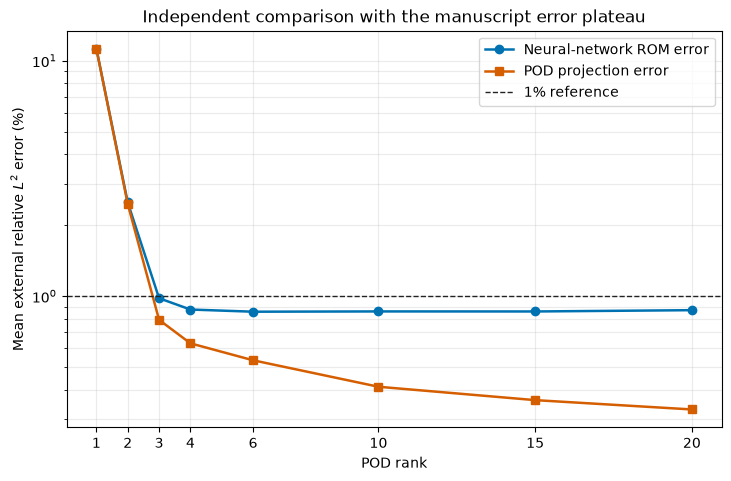

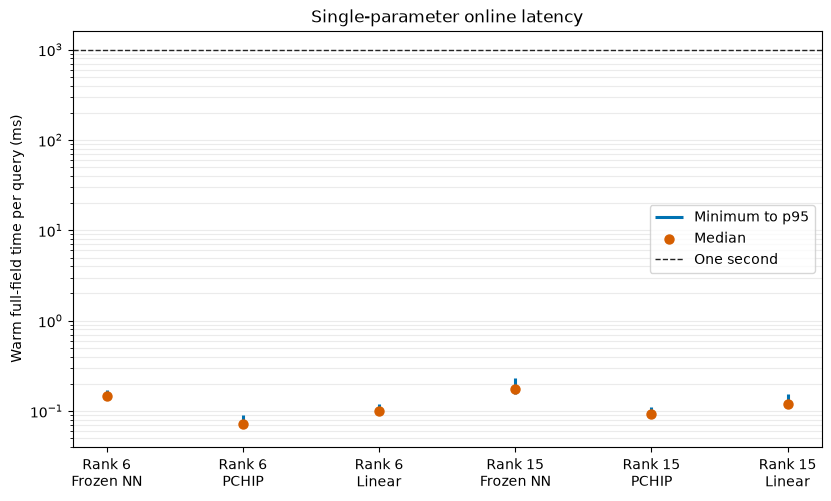

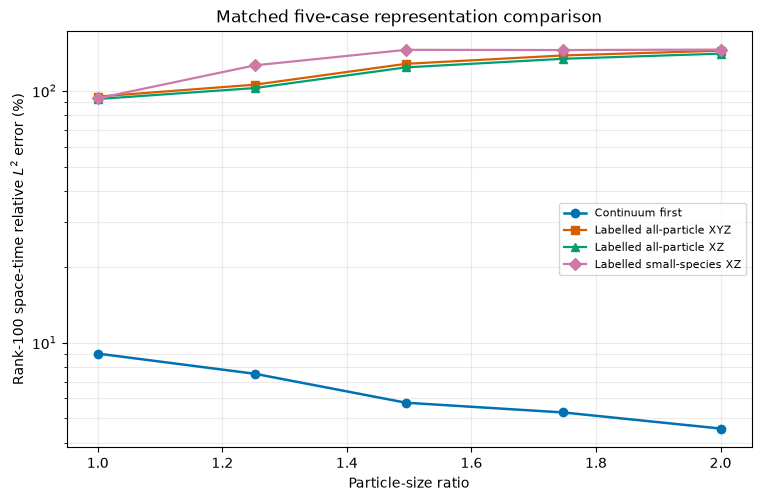

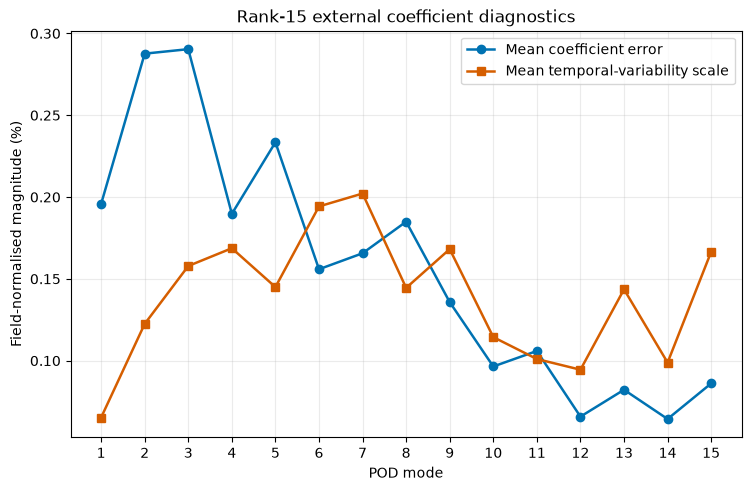

Saved Notebook 20 tables: 19
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/manuscript_comparison_runtime/upstream_manifest_audit.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/manuscript_comparison_runtime/input_audit.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/manuscript_comparison_runtime/input_schema_audit.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/manuscript_comparison_runtime/manuscript_claim_register.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/manuscript_comparison_runtime/continuum_manuscript_comparison.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/manuscript_comparison_runtime/rank_training_view.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/manuscript_comparison_runtime/variability_comparison.csv
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/manuscript_comparison_runtime/external_baseline_comparison.csv
/Us

In [10]:
import matplotlib.pyplot as plt


N20_TABLE_DIRECTORY = (
    N20_REPO_ROOT
    / "results"
    / "tables"
    / "manuscript_comparison_runtime"
)

N20_FIGURE_DIRECTORY = (
    N20_REPO_ROOT
    / "results"
    / "figures"
    / "manuscript_comparison_runtime"
)


N20_TABLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

N20_FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)


def n20_write_csv_atomic(
    table,
    path,
):
    temporary_path = path.with_suffix(
        ".tmp.csv"
    )

    table.to_csv(
        temporary_path,
        index=False,
    )

    temporary_path.replace(path)


N20_TABLE_EXPORTS = {
    "upstream_manifest_audit": (
        N20_MANIFEST_AUDIT
    ),
    "input_audit": (
        N20_INPUT_AUDIT
    ),
    "input_schema_audit": (
        N20_SCHEMA_AUDIT
    ),
    "manuscript_claim_register": (
        N20_MANUSCRIPT_CLAIMS
    ),
    "continuum_manuscript_comparison": (
        N20_CONTINUUM_MANUSCRIPT_COMPARISON
    ),
    "rank_training_view": (
        N20_RANK_TRAINING_VIEW
    ),
    "variability_comparison": (
        N20_VARIABILITY_COMPARISON
    ),
    "external_baseline_comparison": (
        N20_EXTERNAL_BASELINE_COMPARISON
    ),
    "representation_case_comparison": (
        N20_REPRESENTATION_CASE_COMPARISON
    ),
    "representation_summary": (
        N20_REPRESENTATION_SUMMARY
    ),
    "row_continuity_summary": (
        N20_ROW_CONTINUITY_SUMMARY
    ),
    "rank15_external_error_by_ratio": (
        N20_RANK15_EXTERNAL_ERROR_BY_RATIO
    ),
    "model_audit": (
        N20_MODEL_AUDIT
    ),
    "predictor_reproduction_audit": (
        N20_PREDICTOR_REPRODUCTION_AUDIT
    ),
    "timing_raw": (
        N20_TIMING_RAW
    ),
    "timing_summary": (
        N20_TIMING_SUMMARY
    ),
    "rank15_modewise_comparison": (
        N20_RANK15_MODEWISE_COMPARISON
    ),
    "contextual_runtime_comparison": (
        N20_CONTEXTUAL_RUNTIME_COMPARISON
    ),
    "manuscript_evidence": (
        N20_MANUSCRIPT_EVIDENCE
    ),
}


N20_TABLE_PATHS = {
    name: (
        N20_TABLE_DIRECTORY
        / f"{name}.csv"
    )
    for name in N20_TABLE_EXPORTS
}


for name, table in N20_TABLE_EXPORTS.items():
    n20_write_csv_atomic(
        table,
        N20_TABLE_PATHS[name],
    )


N20_FIGURE_PATHS = {
    "rank_error_pdf": (
        N20_FIGURE_DIRECTORY
        / "manuscript_rank_error_plateau.pdf"
    ),
    "rank_error_png": (
        N20_FIGURE_DIRECTORY
        / "manuscript_rank_error_plateau.png"
    ),
    "runtime_pdf": (
        N20_FIGURE_DIRECTORY
        / "external_method_timing.pdf"
    ),
    "runtime_png": (
        N20_FIGURE_DIRECTORY
        / "external_method_timing.png"
    ),
    "representation_pdf": (
        N20_FIGURE_DIRECTORY
        / "representation_route_comparison.pdf"
    ),
    "representation_png": (
        N20_FIGURE_DIRECTORY
        / "representation_route_comparison.png"
    ),
    "modewise_pdf": (
        N20_FIGURE_DIRECTORY
        / "modewise_variability_comparison.pdf"
    ),
    "modewise_png": (
        N20_FIGURE_DIRECTORY
        / "modewise_variability_comparison.png"
    ),
}


N20_COLOURS = {
    "blue": "#0072B2",
    "orange": "#D55E00",
    "green": "#009E73",
    "purple": "#CC79A7",
    "black": "#222222",
}


# Figure 1: rank-dependent projection and ROM errors.
n20_figure, n20_axis = plt.subplots(
    figsize=(7.2, 4.7),
    constrained_layout=True,
)

n20_axis.plot(
    n20_training90["rank"],
    n20_training90[
        "mean_external_error_percent"
    ],
    marker="o",
    linewidth=1.8,
    color=N20_COLOURS["blue"],
    label="Neural-network ROM error",
)

n20_axis.plot(
    n20_training90["rank"],
    n20_training90[
        "mean_projection_error_percent"
    ],
    marker="s",
    linewidth=1.8,
    color=N20_COLOURS["orange"],
    label="POD projection error",
)

n20_axis.axhline(
    1.0,
    color=N20_COLOURS["black"],
    linestyle="--",
    linewidth=1.0,
    label="1% reference",
)

n20_axis.set_yscale("log")
n20_axis.set_xticks(
    n20_training90["rank"]
)
n20_axis.set_xlabel("POD rank")
n20_axis.set_ylabel(
    r"Mean external relative $L^2$ error (%)"
)
n20_axis.set_title(
    "Independent comparison with the manuscript error plateau"
)
n20_axis.grid(
    True,
    which="both",
    alpha=0.25,
)
n20_axis.legend()

n20_figure.savefig(
    N20_FIGURE_PATHS["rank_error_pdf"],
    bbox_inches="tight",
)

n20_figure.savefig(
    N20_FIGURE_PATHS["rank_error_png"],
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# Figure 2: warm online full-field timing.
n20_full_field_timing = (
    N20_TIMING_SUMMARY.loc[
        N20_TIMING_SUMMARY[
            "operation"
        ].eq("full_field_prediction")
    ]
    .sort_values(
        [
            "rank",
            "method",
        ]
    )
    .reset_index(drop=True)
)

n20_method_labels = {
    "frozen_nn": "Frozen NN",
    "piecewise_linear": "Linear",
    "pchip": "PCHIP",
}

n20_timing_labels = [
    (
        f"Rank {int(row['rank'])}\n"
        f"{n20_method_labels[row['method']]}"
    )
    for _, row in (
        n20_full_field_timing.iterrows()
    )
]

n20_positions = np.arange(
    len(n20_full_field_timing)
)

n20_figure, n20_axis = plt.subplots(
    figsize=(8.2, 4.9),
    constrained_layout=True,
)

n20_axis.vlines(
    n20_positions,
    n20_full_field_timing[
        "minimum_time_per_query_ms"
    ],
    n20_full_field_timing[
        "p95_time_per_query_ms"
    ],
    color=N20_COLOURS["blue"],
    linewidth=2.2,
    label="Minimum to p95",
)

n20_axis.scatter(
    n20_positions,
    n20_full_field_timing[
        "median_time_per_query_ms"
    ],
    color=N20_COLOURS["orange"],
    s=42,
    zorder=3,
    label="Median",
)

n20_axis.axhline(
    1000.0,
    color=N20_COLOURS["black"],
    linestyle="--",
    linewidth=1.0,
    label="One second",
)

n20_axis.set_yscale("log")
n20_axis.set_xticks(
    n20_positions,
    n20_timing_labels,
)
n20_axis.set_ylabel(
    "Warm full-field time per query (ms)"
)
n20_axis.set_title(
    "Single-parameter online latency"
)
n20_axis.grid(
    True,
    which="both",
    axis="y",
    alpha=0.25,
)
n20_axis.legend()

n20_figure.savefig(
    N20_FIGURE_PATHS["runtime_pdf"],
    bbox_inches="tight",
)

n20_figure.savefig(
    N20_FIGURE_PATHS["runtime_png"],
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# Figure 3: continuum-first and tested particle routes.
n20_figure, n20_axis = plt.subplots(
    figsize=(7.5, 4.9),
    constrained_layout=True,
)

n20_axis.plot(
    N20_REPRESENTATION_CASE_COMPARISON[
        "size_ratio"
    ],
    N20_REPRESENTATION_CASE_COMPARISON[
        "continuum_spacetime_error_percent"
    ],
    marker="o",
    linewidth=1.8,
    color=N20_COLOURS["blue"],
    label="Continuum first",
)

n20_axis.plot(
    N20_REPRESENTATION_CASE_COMPARISON[
        "size_ratio"
    ],
    N20_REPRESENTATION_CASE_COMPARISON[
        "labelled_xyz_error_percent"
    ],
    marker="s",
    linewidth=1.6,
    color=N20_COLOURS["orange"],
    label="Labelled all-particle XYZ",
)

n20_axis.plot(
    N20_REPRESENTATION_CASE_COMPARISON[
        "size_ratio"
    ],
    N20_REPRESENTATION_CASE_COMPARISON[
        "XZ_particle_error_percent"
    ],
    marker="^",
    linewidth=1.6,
    color=N20_COLOURS["green"],
    label="Labelled all-particle XZ",
)

n20_axis.plot(
    N20_REPRESENTATION_CASE_COMPARISON[
        "size_ratio"
    ],
    N20_REPRESENTATION_CASE_COMPARISON[
        "small_only_spacetime_error_percent"
    ],
    marker="D",
    linewidth=1.6,
    color=N20_COLOURS["purple"],
    label="Labelled small-species XZ",
)

n20_axis.set_yscale("log")
n20_axis.set_xlabel("Particle-size ratio")
n20_axis.set_ylabel(
    r"Rank-100 space-time relative $L^2$ error (%)"
)
n20_axis.set_title(
    "Matched five-case representation comparison"
)
n20_axis.grid(
    True,
    which="both",
    alpha=0.25,
)
n20_axis.legend(fontsize=8)

n20_figure.savefig(
    N20_FIGURE_PATHS[
        "representation_pdf"
    ],
    bbox_inches="tight",
)

n20_figure.savefig(
    N20_FIGURE_PATHS[
        "representation_png"
    ],
    dpi=300,
    bbox_inches="tight",
)

plt.show()


# Figure 4: coefficient error and temporal variability.
n20_figure, n20_axis = plt.subplots(
    figsize=(7.4, 4.8),
    constrained_layout=True,
)

n20_axis.plot(
    N20_RANK15_MODEWISE_COMPARISON[
        "mode"
    ],
    N20_RANK15_MODEWISE_COMPARISON[
        "mean_coefficient_error_percent"
    ],
    marker="o",
    linewidth=1.8,
    color=N20_COLOURS["blue"],
    label="Mean coefficient error",
)

n20_axis.plot(
    N20_RANK15_MODEWISE_COMPARISON[
        "mode"
    ],
    N20_RANK15_MODEWISE_COMPARISON[
        "mean_modal_variability_percent"
    ],
    marker="s",
    linewidth=1.8,
    color=N20_COLOURS["orange"],
    label="Mean temporal-variability scale",
)

n20_axis.set_xticks(
    N20_RANK15_MODEWISE_COMPARISON[
        "mode"
    ]
)
n20_axis.set_xlabel("POD mode")
n20_axis.set_ylabel(
    "Field-normalised magnitude (%)"
)
n20_axis.set_title(
    "Rank-15 external coefficient diagnostics"
)
n20_axis.grid(
    True,
    alpha=0.25,
)
n20_axis.legend()

n20_figure.savefig(
    N20_FIGURE_PATHS["modewise_pdf"],
    bbox_inches="tight",
)

n20_figure.savefig(
    N20_FIGURE_PATHS["modewise_png"],
    dpi=300,
    bbox_inches="tight",
)

plt.show()


assert len(N20_TABLE_PATHS) == 19
assert len(N20_FIGURE_PATHS) == 8

assert all(
    path.is_file()
    for path in N20_TABLE_PATHS.values()
)

assert all(
    path.is_file()
    for path in N20_FIGURE_PATHS.values()
)


print(
    "Saved Notebook 20 tables:",
    len(N20_TABLE_PATHS),
)

for path in N20_TABLE_PATHS.values():
    print(path)

print(
    "Saved Notebook 20 figures:",
    len(N20_FIGURE_PATHS),
)

for path in N20_FIGURE_PATHS.values():
    print(path)

print("Raw DEM files accessed:", False)
print(
    "Original manuscript implementation executed:",
    False,
)
print(
    "Notebook 20 tables and vector figures "
    "saved successfully:",
    True,
)

In [11]:
N20_FINAL_MANIFEST_PATH = (
    N20_TABLE_DIRECTORY
    / "notebook20_final_integrity_manifest.json"
)


n20_input_records = []


for role, relative_path in (
    N20_INPUT_RELATIVE_PATHS.items()
):
    path = N20_INPUT_PATHS[role]

    audit_row = (
        N20_INPUT_AUDIT.loc[
            N20_INPUT_AUDIT[
                "input_role"
            ].eq(role)
        ]
        .iloc[0]
    )

    n20_upstream_hash_available = bool(
        audit_row[
            "upstream_hash_available"
        ]
    )

    n20_input_records.append(
        {
            "input_role": role,
            "relative_path": relative_path,
            "size_bytes": int(
                path.stat().st_size
            ),
            "sha256": str(
                audit_row["sha256"]
            ),
            "upstream_hash_available": (
                n20_upstream_hash_available
            ),
            "upstream_hash_match": (
                bool(
                    audit_row[
                        "upstream_hash_match"
                    ]
                )
                if n20_upstream_hash_available
                else None
            ),
        }
    )


n20_artifact_paths = [
    *N20_TABLE_PATHS.values(),
    *N20_FIGURE_PATHS.values(),
]


assert len(n20_artifact_paths) == 27
assert len(set(n20_artifact_paths)) == 27

assert (
    N20_FINAL_MANIFEST_PATH
    not in n20_artifact_paths
)


n20_artifact_records = []


for path in sorted(
    n20_artifact_paths,
    key=lambda value: str(value),
):
    n20_artifact_records.append(
        {
            "relative_path": str(
                path.relative_to(
                    N20_REPO_ROOT
                )
            ),
            "size_bytes": int(
                path.stat().st_size
            ),
            "sha256": n20_sha256(path),
        }
    )


n20_thread_records = []


for record in (
    N20_THREADPOOL_INFO_DURING_TIMING
):
    n20_thread_records.append(
        {
            "user_api": record.get(
                "user_api"
            ),
            "internal_api": record.get(
                "internal_api"
            ),
            "num_threads": record.get(
                "num_threads"
            ),
            "prefix": record.get(
                "prefix"
            ),
            "version": record.get(
                "version"
            ),
            "threading_layer": record.get(
                "threading_layer"
            ),
            "architecture": record.get(
                "architecture"
            ),
        }
    )


N20_FINAL_MANIFEST = {
    "schema_version": 1,
    "notebook": (
        "20_manuscript_comparison_and_runtime_validation.ipynb"
    ),
    "created_at_utc": (
        datetime.now(timezone.utc).isoformat()
    ),
    "protocol_frozen_at_utc": (
        N20_PROTOCOL_FROZEN_AT_UTC
    ),
    "package_versions": (
        N20_PACKAGE_VERSIONS
    ),
    "source_manifest_hashes": (
        N20_EXPECTED_MANIFEST_HASHES
    ),
    "input_count": len(
        n20_input_records
    ),
    "inputs": n20_input_records,
    "timing_protocol": {
        "cpu_only": True,
        "warmup_calls": (
            N20_WARMUP_CALLS
        ),
        "timing_blocks": (
            N20_TIMING_BLOCKS
        ),
        "calls_per_block": (
            N20_CALLS_PER_BLOCK
        ),
        "total_timed_calls_per_configuration": (
            N20_TOTAL_CALLS_PER_CONFIGURATION
        ),
        "single_parameter_query": True,
        "model_loading_included": False,
        "offline_construction_included": False,
        "disk_io_included": False,
        "thread_configuration_during_timing": (
            n20_thread_records
        ),
    },
    "rank15_warm_full_field_result": {
        "median_time_per_query_ms": (
            N20_RANK15_WARM_MEDIAN_MS
        ),
        "p95_time_per_query_ms": (
            N20_RANK15_WARM_P95_MS
        ),
        "p95_below_one_second": bool(
            N20_RANK15_WARM_P95_UNDER_ONE_SECOND
        ),
    },
    "scope": {
        "raw_dem_files_accessed": False,
        "external_test_used_for_selection": False,
        "original_manuscript_code_executed": False,
        "new_dem_simulation_executed": False,
        "dem_runtime_independently_timed": False,
        "end_to_end_speedup_established": False,
        "manuscript_mixing_index_recreated": False,
        "particle_identity_established": False,
        "particle_comparison_scope": (
            "tested labelled-coordinate POD "
            "representations only"
        ),
    },
    "manuscript_evidence": (
        N20_MANUSCRIPT_EVIDENCE.to_dict(
            orient="records"
        )
    ),
    "table_count": len(
        N20_TABLE_PATHS
    ),
    "figure_count": len(
        N20_FIGURE_PATHS
    ),
    "recorded_artifact_count": len(
        n20_artifact_records
    ),
    "artifacts": n20_artifact_records,
    "hash_scope_note": (
        "The manifest and notebook are excluded "
        "from the artifact records to avoid "
        "self-reference and save-induced notebook "
        "hash changes."
    ),
}


n20_temporary_manifest_path = (
    N20_FINAL_MANIFEST_PATH.with_suffix(
        ".tmp.json"
    )
)

n20_temporary_manifest_path.write_text(
    json.dumps(
        N20_FINAL_MANIFEST,
        indent=2,
    ),
    encoding="utf-8",
)

n20_temporary_manifest_path.replace(
    N20_FINAL_MANIFEST_PATH
)


n20_reloaded_manifest = json.loads(
    N20_FINAL_MANIFEST_PATH.read_text(
        encoding="utf-8"
    )
)


assert (
    n20_reloaded_manifest[
        "recorded_artifact_count"
    ]
    == 27
)

assert (
    n20_reloaded_manifest[
        "table_count"
    ]
    == 19
)

assert (
    n20_reloaded_manifest[
        "figure_count"
    ]
    == 8
)


n20_artifact_errors = []


for record in (
    n20_reloaded_manifest["artifacts"]
):
    path = (
        N20_REPO_ROOT
        / record["relative_path"]
    )

    if not path.is_file():
        n20_artifact_errors.append(
            "missing: "
            + record["relative_path"]
        )
        continue

    if (
        path.stat().st_size
        != record["size_bytes"]
    ):
        n20_artifact_errors.append(
            "size mismatch: "
            + record["relative_path"]
        )

    if (
        n20_sha256(path)
        != record["sha256"]
    ):
        n20_artifact_errors.append(
            "hash mismatch: "
            + record["relative_path"]
        )


n20_input_errors = []


for record in (
    n20_reloaded_manifest["inputs"]
):
    path = (
        N20_REPO_ROOT
        / record["relative_path"]
    )

    if not path.is_file():
        n20_input_errors.append(
            "missing: "
            + record["relative_path"]
        )
        continue

    if (
        path.stat().st_size
        != record["size_bytes"]
    ):
        n20_input_errors.append(
            "size mismatch: "
            + record["relative_path"]
        )

    if (
        n20_sha256(path)
        != record["sha256"]
    ):
        n20_input_errors.append(
            "hash mismatch: "
            + record["relative_path"]
        )


assert not n20_artifact_errors, (
    n20_artifact_errors
)

assert not n20_input_errors, (
    n20_input_errors
)


print(
    "Notebook 20 manifest:",
    N20_FINAL_MANIFEST_PATH,
)
print(
    "Manifest SHA-256:",
    n20_sha256(
        N20_FINAL_MANIFEST_PATH
    ),
)
print(
    "Recorded inputs:",
    len(
        n20_reloaded_manifest["inputs"]
    ),
)
print(
    "Recorded artifacts:",
    len(
        n20_reloaded_manifest["artifacts"]
    ),
)
print(
    "CSV tables:",
    len(N20_TABLE_PATHS),
)
print(
    "PDF figures:",
    sum(
        path.suffix == ".pdf"
        for path in N20_FIGURE_PATHS.values()
    ),
)
print(
    "PNG figures:",
    sum(
        path.suffix == ".png"
        for path in N20_FIGURE_PATHS.values()
    ),
)
print(
    "All input hashes unchanged:",
    True,
)
print(
    "All artifact hashes and sizes match:",
    True,
)
print("Raw DEM files accessed:", False)
print(
    "Independent end-to-end speed-up established:",
    False,
)
print(
    "Notebook 20 final integrity verification passed:",
    True,
)

Notebook 20 manifest: /Users/rallen/Documents/msc-rom-particle-systems/results/tables/manuscript_comparison_runtime/notebook20_final_integrity_manifest.json
Manifest SHA-256: 126c1acc364be3f4e176382592b27de67d1b71c9ff999de3dfebd2104d1c2079
Recorded inputs: 22
Recorded artifacts: 27
CSV tables: 19
PDF figures: 4
PNG figures: 4
All input hashes unchanged: True
All artifact hashes and sizes match: True
Raw DEM files accessed: False
Independent end-to-end speed-up established: False
Notebook 20 final integrity verification passed: True


# Findings and consequences for the dissertation

## Summary of evidence

| Manuscript claim or comparison | Assessment | Principal evidence |
|---|---|---|
| Low-rank continuum representation | Corroborated | Rank-15 POD tail 0.298125%; retained energy 99.999111% |
| Approximately 1% neural-network error plateau | Corroborated | Rank-15 mean external error 0.859868%; rank 4–20 spread only 0.018462 percentage points |
| Error comparable with temporal variability | Partially corroborated | Field-level ratio 0.923686, but coefficient-level ratio 1.364559 |
| Field evaluation below one second | Corroborated for warm online prediction | Rank-15 full-field p95 latency 0.232919 ms using one CPU thread |
| Approximately three-day DEM-to-ROM speed-up | Not independently verified | DEM duration was manuscript-reported and no matched end-to-end timing was performed |
| Manuscript mixing index | Not directly tested | The diagnostic was not independently recreated |
| Continuum-first versus labelled particle-coordinate POD | Corroborated for the tested representations | Mean rank-100 error 6.433% for continuum first, compared with 118.648%–131.079% for the particle representations |

The assessments apply only to the available artifacts and stated experimental protocols. They do not constitute an exact reproduction of the manuscript authors’ original implementation.
## Directly corroborated manuscript findings

The independent reconstruction supports the manuscript’s central continuum-ROM results for the small-species XZ volume-fraction field.

At rank 15, the uncentred POD tail is 0.298125% and the retained energy is 99.999111%. The external neural-network error has mean 0.859868%, median 0.825467% and maximum 1.449864%, with mean spatial correlation 0.999949.

Using 90 fitting cases, the mean external error across ranks 4, 6, 10, 15 and 20 lies between 0.857850% and 0.876312%. The spread is only 0.018462 percentage points. This independently corroborates the manuscript’s claim that prediction error reaches an approximately 1% plateau once the dominant modes have been retained.

## Neural network and interpolation baselines

For rank 15, the frozen neural network gives mean external error 0.859868%, compared with 0.972520% for piecewise-linear interpolation and 1.011759% for PCHIP interpolation. The neural network is therefore slightly more accurate on these ten external cases.

The interpolation baselines are faster during warm online evaluation. This shows that a neural network is not uniquely required for rapid prediction in this one-dimensional parameter study. Its benefit here is the modest accuracy improvement and its potential extensibility to higher-dimensional parameter spaces.

## Temporal variability

At field level, the rank-15 mean ROM error is 0.859868% and the estimated duration-matched field-variability scale is 0.930909%. Their ratio is 0.923686, and six of the ten external errors do not exceed their corresponding field-variability estimate.

The coefficient-level evidence is less uniform. The ratio of mean coefficient error to the retained modal-variability norm is 1.364559, and only four of ten casewise coefficient errors do not exceed that variability scale. Modes 1 and 2 have median error-to-variability ratios of approximately 2.91 and 2.43, whereas many later modes have ratios below or near one.

The field-level similarity therefore supports comparison with temporal variability, but the stronger claim that prediction is uniformly limited by an intrinsic statistical uncertainty is not established. These quantities are empirical finite-duration variability diagnostics, not formal uncertainty bounds.

## Online runtime

The frozen rank-15 neural network reproduces the saved Notebook 14 results to floating-point precision. With the model already loaded, one CPU thread and a single parameter query, prediction of the coefficients and reconstruction of the complete 100 × 100 field has a recorded median latency of 0.174753 ms and a block-mean 95th-percentile latency of 0.232919 ms.

This directly corroborates the manuscript’s claim that an available warm surrogate field evaluation takes less than one second. It excludes model loading, POD construction, network training, disk input/output, coarse-graining and DEM simulation.

The manuscript’s approximately three-day DEM duration was not independently timed. Consequently, this notebook does not establish a matched end-to-end “three days to seconds” speed-up or reproduce the original authors’ implementation.

## Continuum-first and particle-coordinate representations

Across the five matched rank-100 cases, the continuum-first route has mean space-time error 6.433%. The corresponding means are 122.122% for labelled all-particle XYZ, 118.648% for labelled all-particle XZ, and 131.079% for labelled small-species XZ.

The particle-route errors are approximately 10 to 32 times the continuum-first errors across these cases. Removing the unused coordinate or restricting the representation to the particles supporting the observable does not close the gap.

This conclusion applies only to the tested labelled-coordinate POD constructions. The row-continuity audit found that the stored partner was the nearest same-species particle in only about 4.19% of adjacent comparisons on average, with a minimum of about 1.45%. Persistent particle identity was therefore not established, and the results must not be generalised to permutation-invariant, transport-based or graph-based particle representations.

## Overall comparison

The accessible evidence corroborates the manuscript’s principal low-rank continuum representation, approximately 1% external-error plateau and sub-second warm field-evaluation claims.

The temporal-variability interpretation is supported at aggregate field level but requires qualification at coefficient level. The manuscript mixing index, approximately three-day DEM runtime and exact original implementation were not independently reproduced.

Accordingly, the work constitutes an independent, architecture-faithful corroboration of the available continuum-ROM method rather than an exact reproduction of the complete unpublished study.